🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset.xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
📊 Initial dataset shape: (1002, 85)
🎯 Enter target column (e.g., CI, BF1, BF3): BG_01

🎯 Target: BG_01
📁 Output folder: bg_01_comprehensive_outputs_lgbm/
🎯 Found target column (exact): BG_01

📈 TARGET ANALYSIS: BG_01
----------------------------------------
Value distribution:
BG_01
0    533
1    469
Name: count, dtype: int64
Unique values: [np.int64(0), np.int64(1)]
🎯 Final class balance: {0: 0.532, 1: 0.468}
✅ Clean dataset: (1002, 85) (after removing invalid target rows)

🔧 FEATURE ENGINEERING
----------------------------------------
📊 Found 84 numeric features
🔄 Handling missing values with median imputation...
✅ Final feature matrix: (1002, 84) (rows, cols)

🔍 PERFORMING 10-FOLD CROSS-VALIDATION
📊 CROSS-VALIDATION RESULTS (Mean ± Std):
----------------------------------------
ACCURACY       : 0.8952 ± 0.0256 (train: 1.0000)
PRECISION      : 0.8897 ± 0.0306 (train: 1.

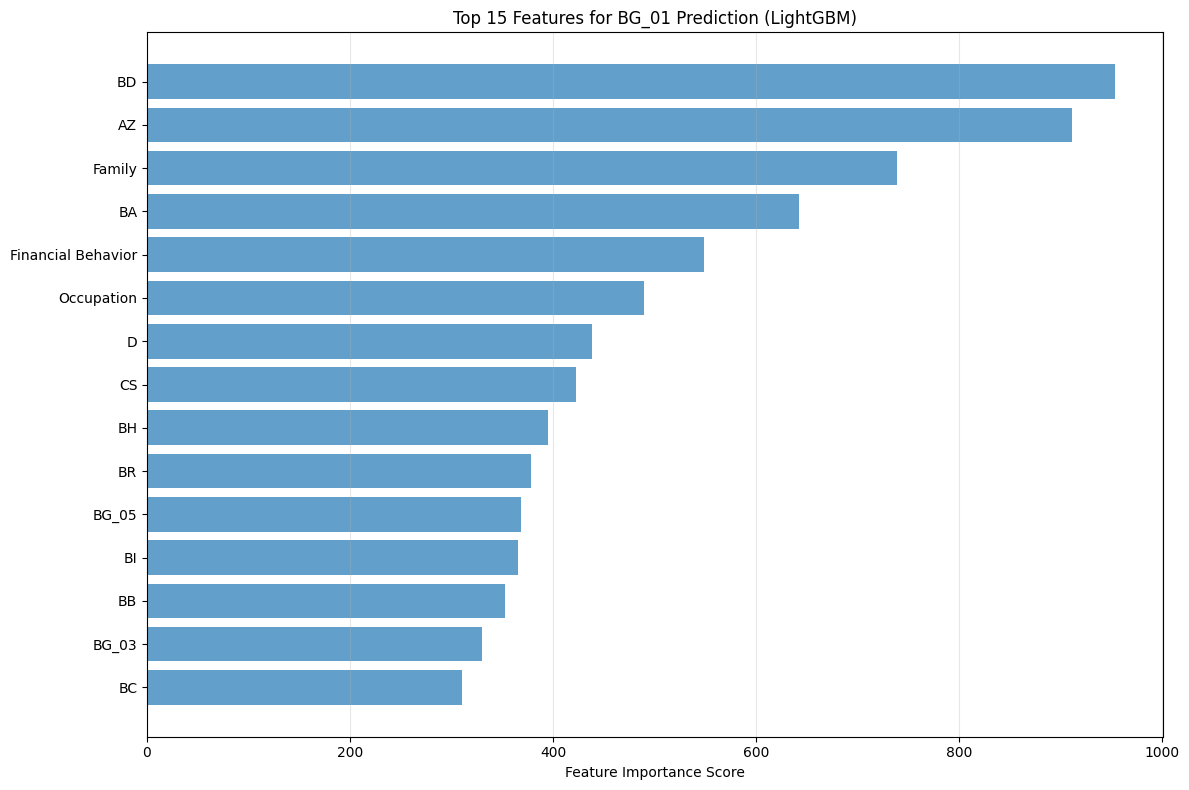

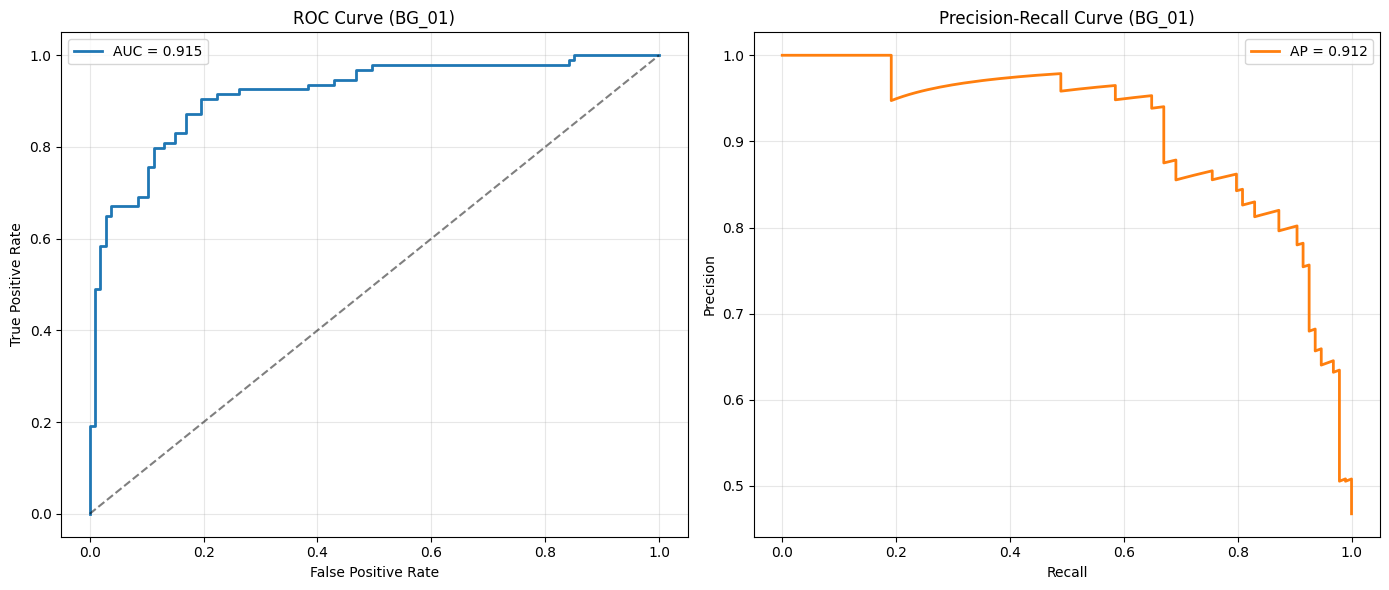

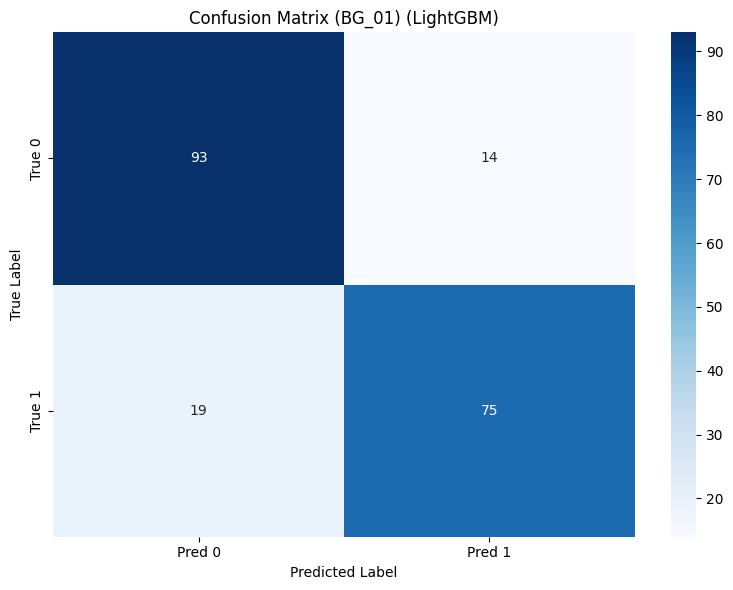

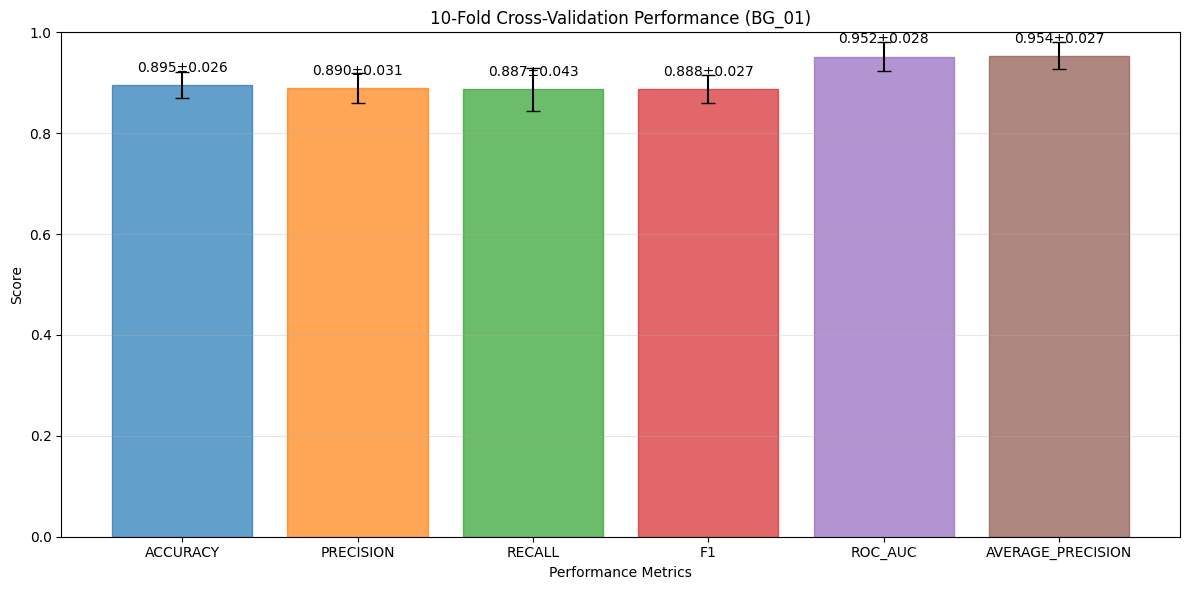


💾 SAVING OUTPUTS to bg_01_comprehensive_outputs_lgbm/ ...
✅ Saved metrics, plots, predictions, and model.

✅ DONE.


In [ ]:
"""
Reusable LightGBM Pipeline for Microfinance Impact Analysis
----------------------------------------------------------
Matches your RF/XGBoost pipeline structure:
- Universal target detection (CI, BF1, BF_1, BF 1, bf-1, etc.)
- Median imputation + StandardScaler in a Pipeline
- 10-fold Stratified CV with multiple metrics
- Train/Test/Validation split option
- Comprehensive evaluation + plots + saving outputs (metrics, preds, model, feature importances)

NOTE:
- This is for binary classification (0/1 target).
"""

# ==============
# 0) INSTALLS
# ==============
# If you're in Colab, uncomment:
# !pip -q install lightgbm openpyxl joblib

# ===========
# 0) IMPORTS
# ===========
import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

from lightgbm import LGBMClassifier

RANDOM_STATE = 42


# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e


def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df


# =========================================================
# 2) UNIVERSAL TARGET SELECTION
# =========================================================
def detect_target_column(df: pd.DataFrame, target: str) -> str:
    """
    Universal target detector:
    1) If `target` matches an existing column exactly -> use it.
    2) If target looks like BF<number>, try common BF aliases (BF 1, BF_1, bf-1, etc.).
    3) Else try case-insensitive exact match.
    4) Else ask user to type exact column name.
    """
    if target is None or str(target).strip() == "":
        raise ValueError("target cannot be empty. Example: target='CI' or target='BF1'")

    target = str(target).strip()

    # (1) Exact match
    if target in df.columns:
        print(f"🎯 Found target column (exact): {target}")
        return target

    # (2) BF alias support if user typed BF-style
    m = re.match(r"^\s*BF\s*(\d+)\s*$", target, flags=re.I)
    if m:
        k = m.group(1)
        aliases = [
            f"BF{k}", f"bf{k}",
            f"BF {k}", f"bf {k}",
            f"BF_{k}", f"bf_{k}",
            f"BF-{k}", f"bf-{k}",
        ]
        for a in aliases:
            if a in df.columns:
                print(f"🎯 Found target column (BF alias): {a}")
                return a

        pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
        for col in df.columns:
            if pat.search(str(col)):
                print(f"🎯 Found target column (BF regex): {col}")
                return col

    # (3) Case-insensitive exact match
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    if target.lower() in lower_map:
        real_col = lower_map[target.lower()]
        print(f"🎯 Found target column (case-insensitive): {real_col}")
        return real_col

    # (4) Ask user
    print(f"❌ Target column '{target}' not found automatically.")
    print("📊 Available columns:")
    print(df.columns.tolist())
    user_col = input("🔍 Enter the exact target column name: ").strip()
    if user_col in df.columns:
        print(f"✅ Using specified target column: {user_col}")
        return user_col
    raise ValueError(f"Column '{user_col}' not found in dataset")


def preprocess_target_binary(y_series: pd.Series, target_label: str):
    """
    Convert target responses into binary classification (expects 0/1 after cleaning).
    """
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label} after cleaning")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:")
    print(y_clean.value_counts().sort_index())

    unique_vals = sorted(y_clean.unique())
    print(f"Unique values: {unique_vals}")

    y_binary = y_clean.astype(int)

    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask


# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    """Prepare features for ML (numeric-only)."""
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    print(f"📊 Found {len(numeric_cols)} numeric features")

    if len(numeric_cols) == 0:
        raise ValueError("❌ No numeric features found for modeling")

    print("🔄 Handling missing values with median imputation...")
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    dropped = len(numeric_cols) - len(non_constant_cols)
    if dropped > 0:
        print(f"🗑️  Removed {dropped} constant columns")

    X_final = X_imputed[non_constant_cols]
    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols


# =========================================================
# 4) CROSS-VALIDATION
# =========================================================
def _compute_class_weight_for_lgbm(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    if pos == 0:
        return 1.0
    return neg / pos


def perform_cross_validation(X, y, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION")
    print("=" * 50)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        test_mean = float(np.mean(test_scores))
        test_std = float(np.std(test_scores))
        train_mean = float(np.mean(train_scores))

        metrics_summary[metric] = {
            "test_mean": test_mean,
            "test_std": test_std,
            "train_mean": train_mean
        }

        print(f"{metric.upper():<15}: {test_mean:.4f} ± {test_std:.4f} (train: {train_mean:.4f})")

    overfit_gap = metrics_summary["accuracy"]["train_mean"] - metrics_summary["accuracy"]["test_mean"]
    print(f"\n📈 Overfitting Analysis:")
    print(f"   Train-Test Accuracy Gap: {overfit_gap:.4f}")
    print("   ⚠️  Potential overfitting detected" if overfit_gap > 0.05 else "   ✅ Model generalizes well")

    return metrics_summary, cv_results


# =========================================================
# 5) TRAIN/TEST/VALIDATION SPLITS + TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING VALIDATION SET ({validation_size*100:.0f}% of data)")
    print("=" * 50)

    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )

    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print(f"✅ Validation set: {X_val.shape[0]} samples")

    return X_train, X_test, X_val, y_train, y_test, y_val


def train_with_comprehensive_validation(X, y, use_validation_set=True):
    print("\n🎯 MODEL TRAINING: LightGBM")
    print("-" * 40)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
        print("🔧 Training model with regularization...")
        pipe.fit(X_train, y_train)
        return pipe, X_train, X_test, X_val, y_train, y_test, y_val

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print("🔧 Training model with regularization...")
    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, None, y_train, y_test, None


# =========================================================
# 6) EVALUATION
# =========================================================
def evaluate_model_comprehensive(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET COMPREHENSIVE EVALUATION")
    print("=" * 60)
    print(f"🎯 Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"🎯 Recall:    {rec:.4f}")
    print(f"🎯 F1-Score:  {f1:.4f}")
    print(f"📈 ROC-AUC:   {roc_auc:.4f}")
    print(f"📈 PR-AUC:    {pr_auc:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    print(f"📊 {dataset_name} Confusion Matrix:")
    print("[[TN FP]\n [FN TP]]")
    print(cm)

    return y_pred, y_proba, {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc
    }


# =========================================================
# 7) VISUALIZATIONS
# =========================================================
def create_validation_comparison_plot(cv_metrics, output_dir, prefix):
    metrics_names = list(cv_metrics.keys())
    test_means = [cv_metrics[m]["test_mean"] for m in metrics_names]
    test_stds = [cv_metrics[m]["test_std"] for m in metrics_names]

    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(metrics_names))
    bars = plt.bar(x_pos, test_means, yerr=test_stds, capsize=5, alpha=0.7)

    for i, b in enumerate(bars):
        b.set_color(f"C{i}")

    plt.xlabel("Performance Metrics")
    plt.ylabel("Score")
    plt.title(f"10-Fold Cross-Validation Performance ({prefix.upper()})")
    plt.xticks(x_pos, [m.upper() for m in metrics_names], rotation=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis="y")

    for i, (mean, std) in enumerate(zip(test_means, test_stds)):
        plt.text(i, mean + 0.02, f"{mean:.3f}±{std:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_cross_validation_results.png", dpi=200, bbox_inches="tight")
    plt.show()


def create_comprehensive_visualizations(y_test, y_proba, model, feature_names, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    lgbm_model = model.named_steps["lgbm"]
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": lgbm_model.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"{output_dir}/{prefix}_feature_importances.csv", index=False)

    # Feature importance plot
    plt.figure(figsize=(12, 8))
    top_features = imp_df.head(15).iloc[::-1]
    plt.barh(range(len(top_features)), top_features["importance"], alpha=0.7)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Feature Importance Score")
    plt.title(f"Top 15 Features for {prefix.upper()} Prediction (LightGBM)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_feature_importances.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ROC + PR curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve ({prefix.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision-Recall Curve ({prefix.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Confusion matrix heatmap
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({prefix.upper()}) (LightGBM)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    if cv_metrics:
        create_validation_comparison_plot(cv_metrics, output_dir, prefix)

    return imp_df


# =========================================================
# 8) SAVE RESULTS
# =========================================================
def save_comprehensive_results(model, metrics, imp_df, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")
    os.makedirs(output_dir, exist_ok=True)

    with open(f"{output_dir}/{prefix}_comprehensive_metrics.txt", "w", encoding="utf-8") as f:
        f.write(f"COMPREHENSIVE LIGHTGBM RESULTS ({prefix.upper()})\n")
        f.write("=" * 60 + "\n")
        f.write(f"Dataset shape: {df_clean.shape}\n")
        f.write(f"Target column: {target_col}\n")
        f.write(f"Features used: {len(feature_names)}\n\n")

        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v:.4f}\n")
        f.write("\n")

        if cv_metrics:
            f.write("10-FOLD CROSS-VALIDATION (Mean ± Std) WITH MULTIPLE METRICS:\n")
            for metric, scores in cv_metrics.items():
                f.write(f"{metric}: {scores['test_mean']:.4f} ± {scores['test_std']:.4f}\n")
            f.write("\n")

        f.write("TOP 10 FEATURES:\n")
        for _, row in imp_df.head(10).iterrows():
            f.write(f"{row['feature']}: {row['importance']:.6f}\n")

    # Full-dataset predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore")
    X_full = X_full.reindex(columns=feature_names)

    preds = model.predict_proba(X_full)[:, 1]
    predictions_df = df_clean.copy()
    predictions_df[f"{prefix}_Pred_Prob"] = preds
    predictions_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    predictions_df[f"{prefix}_Correct"] = (predictions_df[f"{prefix}_Pred"] == predictions_df[target_col]).astype(int)

    predictions_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)
    joblib.dump(model, f"{output_dir}/{prefix}_lgbm_model.joblib")

    print("✅ Saved metrics, plots, predictions, and model.")


# =========================================================
# 9) MAIN PIPELINE (ASK TARGET AT THE END)
# =========================================================
def run_comprehensive_analysis(
    use_cross_validation=True,
    use_validation_set=True,
    df=None
):
    """
    Same pipeline, but you TYPE the target column at the end (after file load).
    """
    try:
        print("🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)")
        print("=" * 60)

        if df is None:
            try:
                import google.colab  # noqa: F401
                df = load_excel_from_colab()
            except Exception:
                df = load_excel_locally()

        print(f"📊 Initial dataset shape: {df.shape}")
        print("=" * 60)

        # ✅ Ask target at the end (after dataset is loaded)
        target = input("🎯 Enter target column (e.g., CI, BF1, BF3): ").strip()

        prefix = re.sub(r"[^a-zA-Z0-9]+", "_", str(target).strip().lower()).strip("_")
        output_dir = f"{prefix}_comprehensive_outputs_lgbm"

        print(f"\n🎯 Target: {target}")
        print(f"📁 Output folder: {output_dir}/")
        print("=" * 60)

        target_col = detect_target_column(df, target=target)

        y, valid_mask = preprocess_target_binary(df[target_col], target_label=target_col)
        df_clean = df.loc[valid_mask].copy()
        print(f"✅ Clean dataset: {df_clean.shape} (after removing invalid target rows)")

        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        cv_metrics = None
        if use_cross_validation:
            cv_metrics, _ = perform_cross_validation(X_final, y, cv_folds=10)

        model, X_train, X_test, X_val, y_train, y_test, y_val = train_with_comprehensive_validation(
            X_final, y, use_validation_set=use_validation_set
        )

        _, y_proba, test_metrics = evaluate_model_comprehensive(model, X_test, y_test, "Test")

        if X_val is not None and y_val is not None:
            evaluate_model_comprehensive(model, X_val, y_val, "Validation")

        imp_df = create_comprehensive_visualizations(
            y_test=y_test,
            y_proba=y_proba,
            model=model,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        save_comprehensive_results(
            model=model,
            metrics=test_metrics,
            imp_df=imp_df,
            df_clean=df_clean,
            target_col=target_col,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        print("\n✅ DONE.")
        return model, test_metrics, imp_df, cv_metrics

    except Exception as e:
        print(f"\n❌ Analysis failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc(limit=2)
        return None, None, None, None


# ========= RUN =========
if __name__ == "__main__":
    # You will be asked to upload the file, then type the target column name
    run_comprehensive_analysis(use_cross_validation=True, use_validation_set=True)


🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (1).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
📊 Initial dataset shape: (1002, 85)
🎯 Enter target column (e.g., CI, BF1, BF3): BG_03

🎯 Target: BG_03
📁 Output folder: bg_03_comprehensive_outputs_lgbm/
🎯 Found target column (exact): BG_03

📈 TARGET ANALYSIS: BG_03
----------------------------------------
Value distribution:
BG_03
0    590
1    412
Name: count, dtype: int64
Unique values: [np.int64(0), np.int64(1)]
🎯 Final class balance: {0: 0.589, 1: 0.411}
✅ Clean dataset: (1002, 85) (after removing invalid target rows)

🔧 FEATURE ENGINEERING
----------------------------------------
📊 Found 84 numeric features
🔄 Handling missing values with median imputation...
✅ Final feature matrix: (1002, 84) (rows, cols)

🔍 PERFORMING 10-FOLD CROSS-VALIDATION
📊 CROSS-VALIDATION RESULTS (Mean ± Std):
----------------------------------------
ACCURACY       : 0.8713 ± 0.0351 (train: 0.9998)
PRECISION      : 0.8572 ± 0.0487 (train

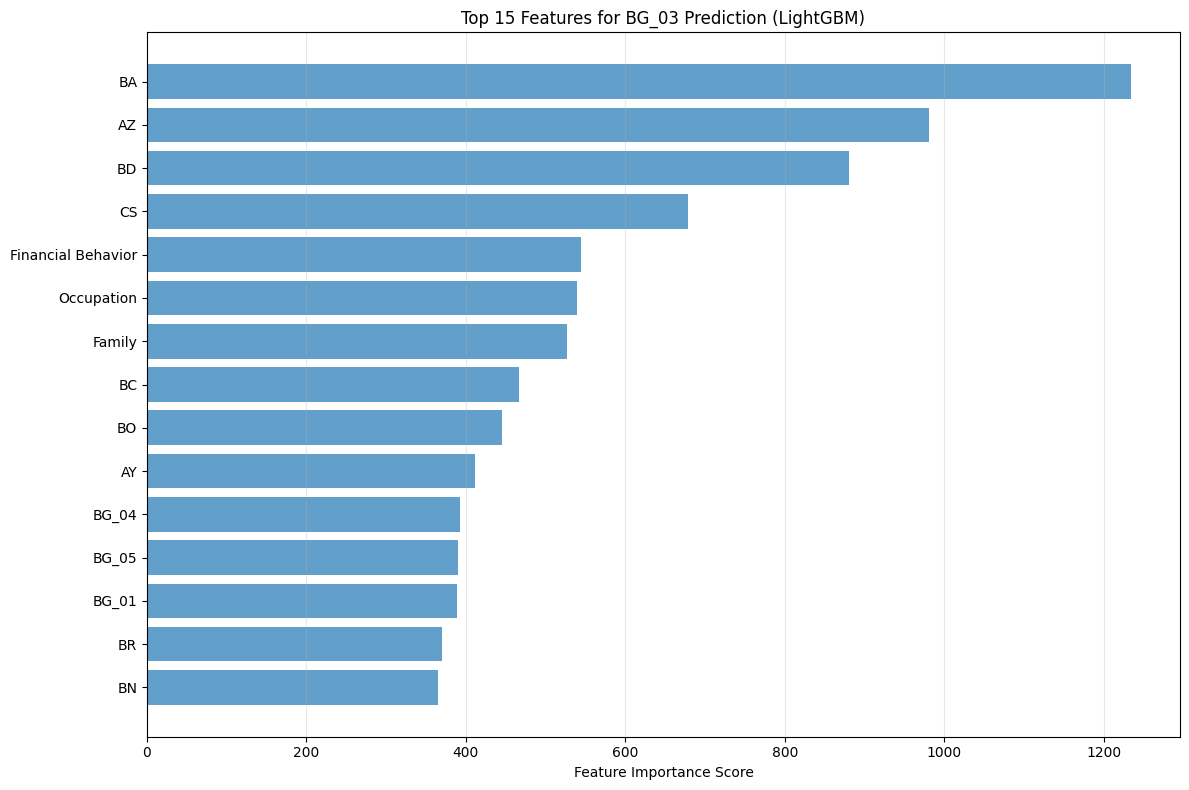

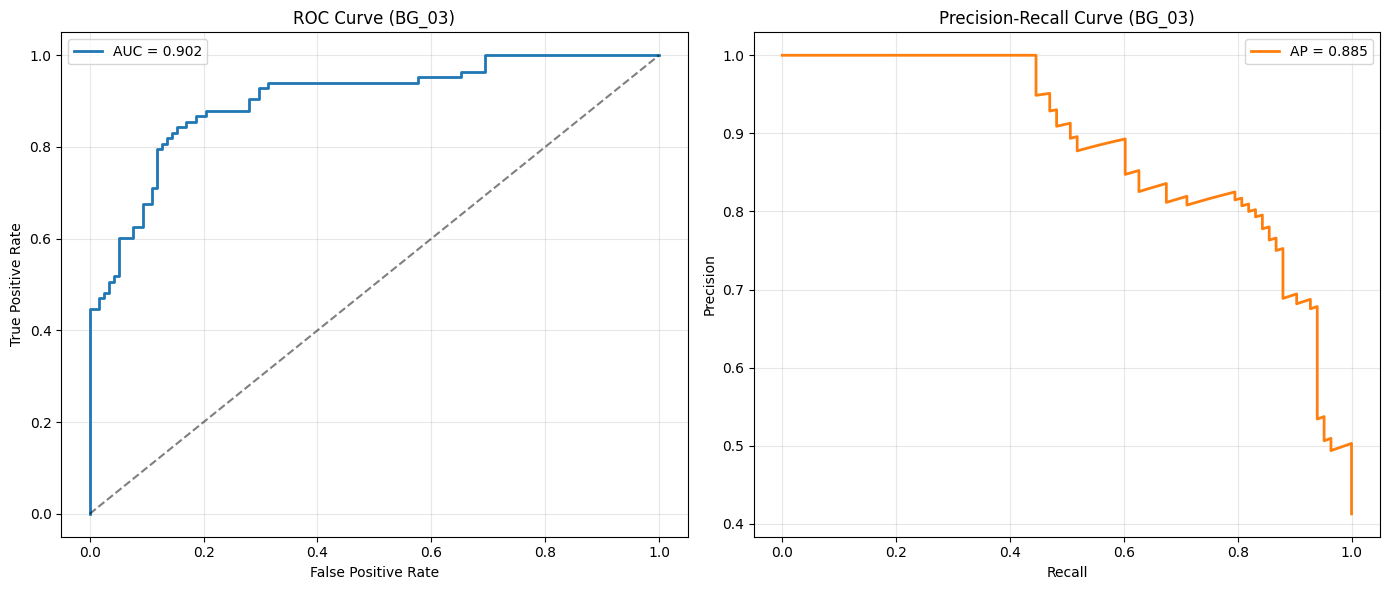

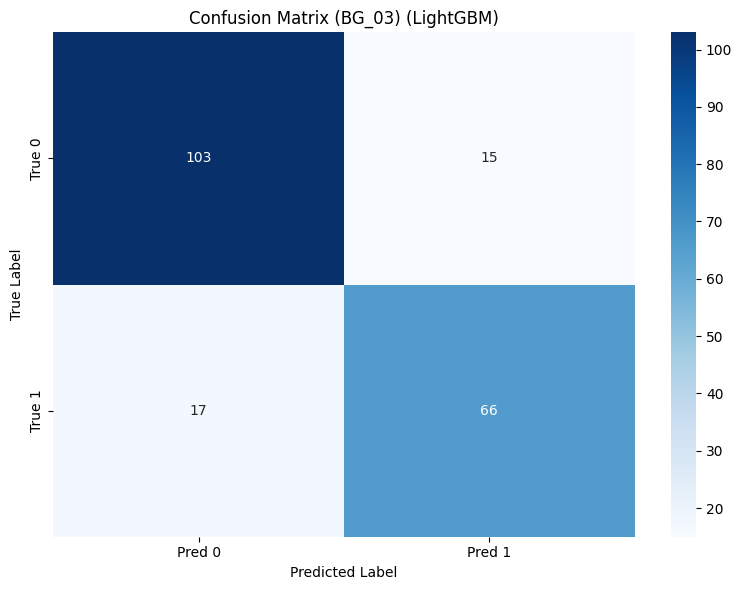

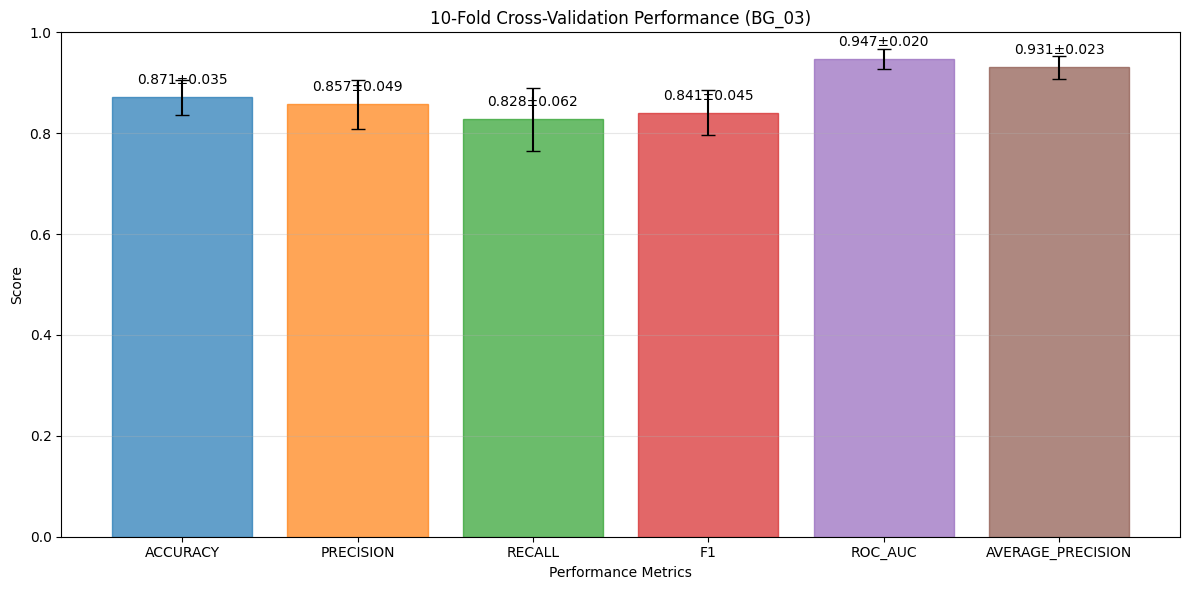


💾 SAVING OUTPUTS to bg_03_comprehensive_outputs_lgbm/ ...
✅ Saved metrics, plots, predictions, and model.

✅ DONE.


In [ ]:
"""
Reusable LightGBM Pipeline for Microfinance Impact Analysis
----------------------------------------------------------
Matches your RF/XGBoost pipeline structure:
- Universal target detection (CI, BF1, BF_1, BF 1, bf-1, etc.)
- Median imputation + StandardScaler in a Pipeline
- 10-fold Stratified CV with multiple metrics
- Train/Test/Validation split option
- Comprehensive evaluation + plots + saving outputs (metrics, preds, model, feature importances)

NOTE:
- This is for binary classification (0/1 target).
"""

# ==============
# 0) INSTALLS
# ==============
# If you're in Colab, uncomment:
# !pip -q install lightgbm openpyxl joblib

# ===========
# 0) IMPORTS
# ===========
import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

from lightgbm import LGBMClassifier

RANDOM_STATE = 42


# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e


def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df


# =========================================================
# 2) UNIVERSAL TARGET SELECTION
# =========================================================
def detect_target_column(df: pd.DataFrame, target: str) -> str:
    """
    Universal target detector:
    1) If `target` matches an existing column exactly -> use it.
    2) If target looks like BF<number>, try common BF aliases (BF 1, BF_1, bf-1, etc.).
    3) Else try case-insensitive exact match.
    4) Else ask user to type exact column name.
    """
    if target is None or str(target).strip() == "":
        raise ValueError("target cannot be empty. Example: target='CI' or target='BF1'")

    target = str(target).strip()

    # (1) Exact match
    if target in df.columns:
        print(f"🎯 Found target column (exact): {target}")
        return target

    # (2) BF alias support if user typed BF-style
    m = re.match(r"^\s*BF\s*(\d+)\s*$", target, flags=re.I)
    if m:
        k = m.group(1)
        aliases = [
            f"BF{k}", f"bf{k}",
            f"BF {k}", f"bf {k}",
            f"BF_{k}", f"bf_{k}",
            f"BF-{k}", f"bf-{k}",
        ]
        for a in aliases:
            if a in df.columns:
                print(f"🎯 Found target column (BF alias): {a}")
                return a

        pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
        for col in df.columns:
            if pat.search(str(col)):
                print(f"🎯 Found target column (BF regex): {col}")
                return col

    # (3) Case-insensitive exact match
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    if target.lower() in lower_map:
        real_col = lower_map[target.lower()]
        print(f"🎯 Found target column (case-insensitive): {real_col}")
        return real_col

    # (4) Ask user
    print(f"❌ Target column '{target}' not found automatically.")
    print("📊 Available columns:")
    print(df.columns.tolist())
    user_col = input("🔍 Enter the exact target column name: ").strip()
    if user_col in df.columns:
        print(f"✅ Using specified target column: {user_col}")
        return user_col
    raise ValueError(f"Column '{user_col}' not found in dataset")


def preprocess_target_binary(y_series: pd.Series, target_label: str):
    """
    Convert target responses into binary classification (expects 0/1 after cleaning).
    """
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label} after cleaning")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:")
    print(y_clean.value_counts().sort_index())

    unique_vals = sorted(y_clean.unique())
    print(f"Unique values: {unique_vals}")

    y_binary = y_clean.astype(int)

    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask


# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    """Prepare features for ML (numeric-only)."""
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    print(f"📊 Found {len(numeric_cols)} numeric features")

    if len(numeric_cols) == 0:
        raise ValueError("❌ No numeric features found for modeling")

    print("🔄 Handling missing values with median imputation...")
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    dropped = len(numeric_cols) - len(non_constant_cols)
    if dropped > 0:
        print(f"🗑️  Removed {dropped} constant columns")

    X_final = X_imputed[non_constant_cols]
    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols


# =========================================================
# 4) CROSS-VALIDATION
# =========================================================
def _compute_class_weight_for_lgbm(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    if pos == 0:
        return 1.0
    return neg / pos


def perform_cross_validation(X, y, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION")
    print("=" * 50)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        test_mean = float(np.mean(test_scores))
        test_std = float(np.std(test_scores))
        train_mean = float(np.mean(train_scores))

        metrics_summary[metric] = {
            "test_mean": test_mean,
            "test_std": test_std,
            "train_mean": train_mean
        }

        print(f"{metric.upper():<15}: {test_mean:.4f} ± {test_std:.4f} (train: {train_mean:.4f})")

    overfit_gap = metrics_summary["accuracy"]["train_mean"] - metrics_summary["accuracy"]["test_mean"]
    print(f"\n📈 Overfitting Analysis:")
    print(f"   Train-Test Accuracy Gap: {overfit_gap:.4f}")
    print("   ⚠️  Potential overfitting detected" if overfit_gap > 0.05 else "   ✅ Model generalizes well")

    return metrics_summary, cv_results


# =========================================================
# 5) TRAIN/TEST/VALIDATION SPLITS + TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING VALIDATION SET ({validation_size*100:.0f}% of data)")
    print("=" * 50)

    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )

    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print(f"✅ Validation set: {X_val.shape[0]} samples")

    return X_train, X_test, X_val, y_train, y_test, y_val


def train_with_comprehensive_validation(X, y, use_validation_set=True):
    print("\n🎯 MODEL TRAINING: LightGBM")
    print("-" * 40)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
        print("🔧 Training model with regularization...")
        pipe.fit(X_train, y_train)
        return pipe, X_train, X_test, X_val, y_train, y_test, y_val

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print("🔧 Training model with regularization...")
    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, None, y_train, y_test, None


# =========================================================
# 6) EVALUATION
# =========================================================
def evaluate_model_comprehensive(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET COMPREHENSIVE EVALUATION")
    print("=" * 60)
    print(f"🎯 Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"🎯 Recall:    {rec:.4f}")
    print(f"🎯 F1-Score:  {f1:.4f}")
    print(f"📈 ROC-AUC:   {roc_auc:.4f}")
    print(f"📈 PR-AUC:    {pr_auc:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    print(f"📊 {dataset_name} Confusion Matrix:")
    print("[[TN FP]\n [FN TP]]")
    print(cm)

    return y_pred, y_proba, {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc
    }


# =========================================================
# 7) VISUALIZATIONS
# =========================================================
def create_validation_comparison_plot(cv_metrics, output_dir, prefix):
    metrics_names = list(cv_metrics.keys())
    test_means = [cv_metrics[m]["test_mean"] for m in metrics_names]
    test_stds = [cv_metrics[m]["test_std"] for m in metrics_names]

    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(metrics_names))
    bars = plt.bar(x_pos, test_means, yerr=test_stds, capsize=5, alpha=0.7)

    for i, b in enumerate(bars):
        b.set_color(f"C{i}")

    plt.xlabel("Performance Metrics")
    plt.ylabel("Score")
    plt.title(f"10-Fold Cross-Validation Performance ({prefix.upper()})")
    plt.xticks(x_pos, [m.upper() for m in metrics_names], rotation=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis="y")

    for i, (mean, std) in enumerate(zip(test_means, test_stds)):
        plt.text(i, mean + 0.02, f"{mean:.3f}±{std:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_cross_validation_results.png", dpi=200, bbox_inches="tight")
    plt.show()


def create_comprehensive_visualizations(y_test, y_proba, model, feature_names, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    lgbm_model = model.named_steps["lgbm"]
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": lgbm_model.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"{output_dir}/{prefix}_feature_importances.csv", index=False)

    # Feature importance plot
    plt.figure(figsize=(12, 8))
    top_features = imp_df.head(15).iloc[::-1]
    plt.barh(range(len(top_features)), top_features["importance"], alpha=0.7)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Feature Importance Score")
    plt.title(f"Top 15 Features for {prefix.upper()} Prediction (LightGBM)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_feature_importances.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ROC + PR curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve ({prefix.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision-Recall Curve ({prefix.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Confusion matrix heatmap
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({prefix.upper()}) (LightGBM)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    if cv_metrics:
        create_validation_comparison_plot(cv_metrics, output_dir, prefix)

    return imp_df


# =========================================================
# 8) SAVE RESULTS
# =========================================================
def save_comprehensive_results(model, metrics, imp_df, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")
    os.makedirs(output_dir, exist_ok=True)

    with open(f"{output_dir}/{prefix}_comprehensive_metrics.txt", "w", encoding="utf-8") as f:
        f.write(f"COMPREHENSIVE LIGHTGBM RESULTS ({prefix.upper()})\n")
        f.write("=" * 60 + "\n")
        f.write(f"Dataset shape: {df_clean.shape}\n")
        f.write(f"Target column: {target_col}\n")
        f.write(f"Features used: {len(feature_names)}\n\n")

        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v:.4f}\n")
        f.write("\n")

        if cv_metrics:
            f.write("10-FOLD CROSS-VALIDATION (Mean ± Std) WITH MULTIPLE METRICS:\n")
            for metric, scores in cv_metrics.items():
                f.write(f"{metric}: {scores['test_mean']:.4f} ± {scores['test_std']:.4f}\n")
            f.write("\n")

        f.write("TOP 10 FEATURES:\n")
        for _, row in imp_df.head(10).iterrows():
            f.write(f"{row['feature']}: {row['importance']:.6f}\n")

    # Full-dataset predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore")
    X_full = X_full.reindex(columns=feature_names)

    preds = model.predict_proba(X_full)[:, 1]
    predictions_df = df_clean.copy()
    predictions_df[f"{prefix}_Pred_Prob"] = preds
    predictions_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    predictions_df[f"{prefix}_Correct"] = (predictions_df[f"{prefix}_Pred"] == predictions_df[target_col]).astype(int)

    predictions_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)
    joblib.dump(model, f"{output_dir}/{prefix}_lgbm_model.joblib")

    print("✅ Saved metrics, plots, predictions, and model.")


# =========================================================
# 9) MAIN PIPELINE (ASK TARGET AT THE END)
# =========================================================
def run_comprehensive_analysis(
    use_cross_validation=True,
    use_validation_set=True,
    df=None
):
    """
    Same pipeline, but you TYPE the target column at the end (after file load).
    """
    try:
        print("🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)")
        print("=" * 60)

        if df is None:
            try:
                import google.colab  # noqa: F401
                df = load_excel_from_colab()
            except Exception:
                df = load_excel_locally()

        print(f"📊 Initial dataset shape: {df.shape}")
        print("=" * 60)

        # ✅ Ask target at the end (after dataset is loaded)
        target = input("🎯 Enter target column (e.g., CI, BF1, BF3): ").strip()

        prefix = re.sub(r"[^a-zA-Z0-9]+", "_", str(target).strip().lower()).strip("_")
        output_dir = f"{prefix}_comprehensive_outputs_lgbm"

        print(f"\n🎯 Target: {target}")
        print(f"📁 Output folder: {output_dir}/")
        print("=" * 60)

        target_col = detect_target_column(df, target=target)

        y, valid_mask = preprocess_target_binary(df[target_col], target_label=target_col)
        df_clean = df.loc[valid_mask].copy()
        print(f"✅ Clean dataset: {df_clean.shape} (after removing invalid target rows)")

        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        cv_metrics = None
        if use_cross_validation:
            cv_metrics, _ = perform_cross_validation(X_final, y, cv_folds=10)

        model, X_train, X_test, X_val, y_train, y_test, y_val = train_with_comprehensive_validation(
            X_final, y, use_validation_set=use_validation_set
        )

        _, y_proba, test_metrics = evaluate_model_comprehensive(model, X_test, y_test, "Test")

        if X_val is not None and y_val is not None:
            evaluate_model_comprehensive(model, X_val, y_val, "Validation")

        imp_df = create_comprehensive_visualizations(
            y_test=y_test,
            y_proba=y_proba,
            model=model,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        save_comprehensive_results(
            model=model,
            metrics=test_metrics,
            imp_df=imp_df,
            df_clean=df_clean,
            target_col=target_col,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        print("\n✅ DONE.")
        return model, test_metrics, imp_df, cv_metrics

    except Exception as e:
        print(f"\n❌ Analysis failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc(limit=2)
        return None, None, None, None


# ========= RUN =========
if __name__ == "__main__":
    # You will be asked to upload the file, then type the target column name
    run_comprehensive_analysis(use_cross_validation=True, use_validation_set=True)


🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (2).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
📊 Initial dataset shape: (1002, 85)
🎯 Enter target column (e.g., CI, BF1, BF3): BG_04

🎯 Target: BG_04
📁 Output folder: bg_04_comprehensive_outputs_lgbm/
🎯 Found target column (exact): BG_04

📈 TARGET ANALYSIS: BG_04
----------------------------------------
Value distribution:
BG_04
0    605
1    397
Name: count, dtype: int64
Unique values: [np.int64(0), np.int64(1)]
🎯 Final class balance: {0: 0.604, 1: 0.396}
✅ Clean dataset: (1002, 85) (after removing invalid target rows)

🔧 FEATURE ENGINEERING
----------------------------------------
📊 Found 84 numeric features
🔄 Handling missing values with median imputation...
✅ Final feature matrix: (1002, 84) (rows, cols)

🔍 PERFORMING 10-FOLD CROSS-VALIDATION
📊 CROSS-VALIDATION RESULTS (Mean ± Std):
----------------------------------------
ACCURACY       : 0.9012 ± 0.0278 (train: 1.0000)
PRECISION      : 0.8747 ± 0.0364 (train

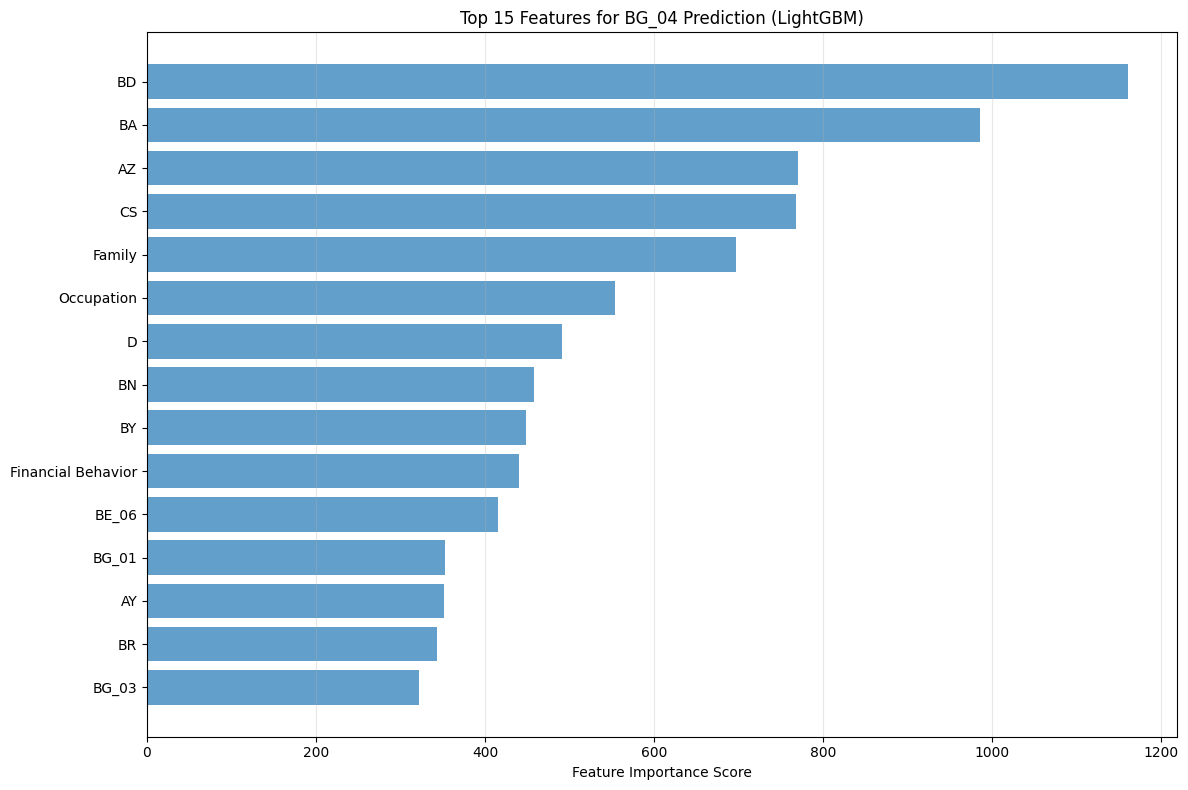

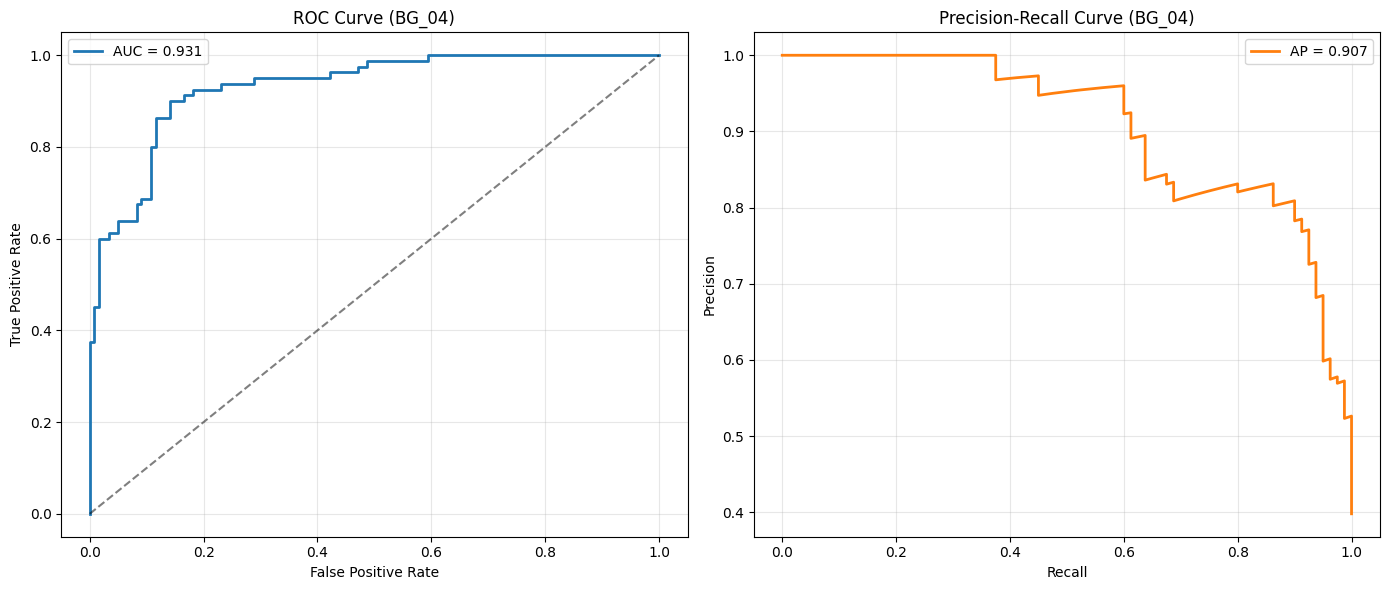

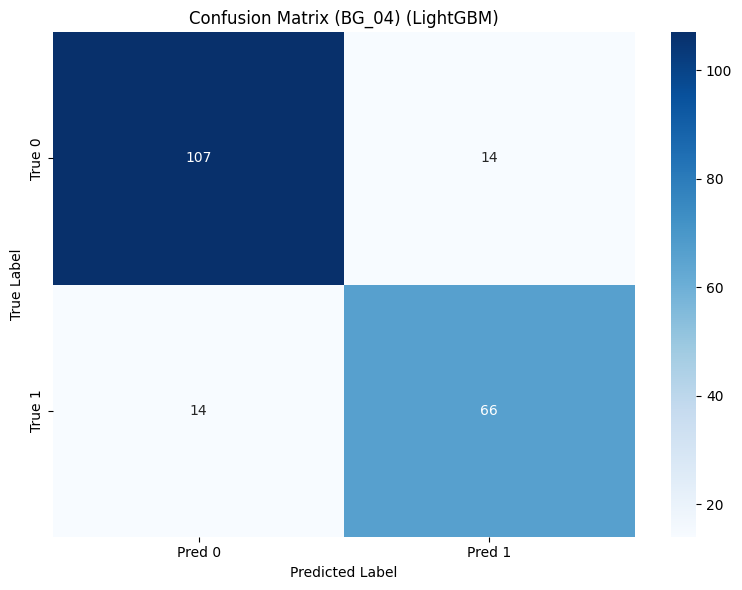

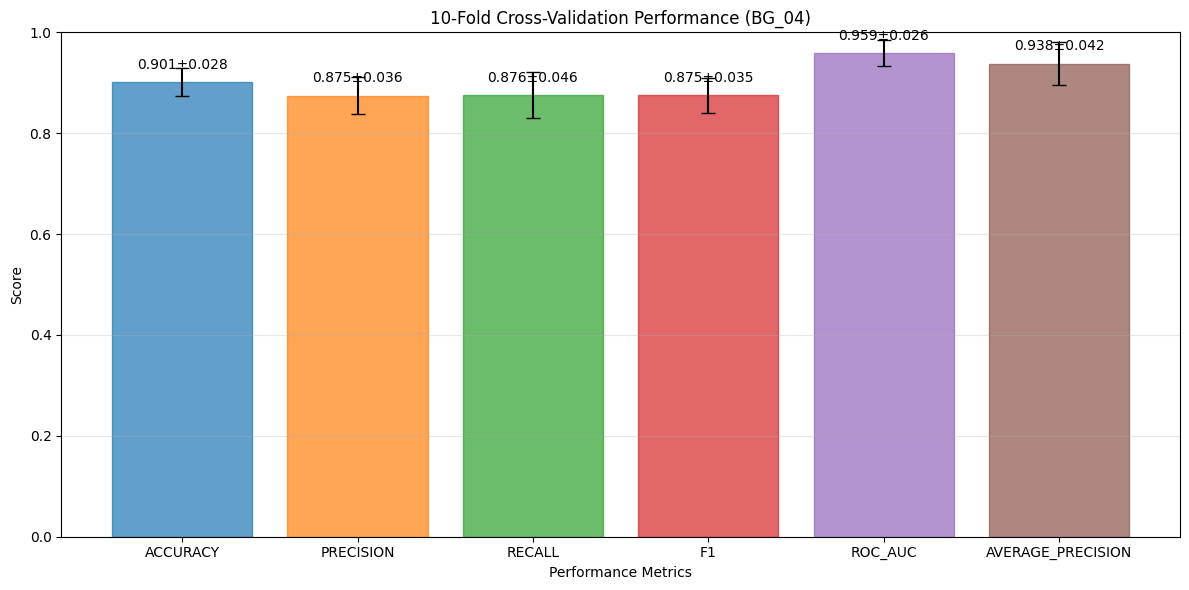


💾 SAVING OUTPUTS to bg_04_comprehensive_outputs_lgbm/ ...
✅ Saved metrics, plots, predictions, and model.

✅ DONE.


In [ ]:
"""
Reusable LightGBM Pipeline for Microfinance Impact Analysis
----------------------------------------------------------
Matches your RF/XGBoost pipeline structure:
- Universal target detection (CI, BF1, BF_1, BF 1, bf-1, etc.)
- Median imputation + StandardScaler in a Pipeline
- 10-fold Stratified CV with multiple metrics
- Train/Test/Validation split option
- Comprehensive evaluation + plots + saving outputs (metrics, preds, model, feature importances)

NOTE:
- This is for binary classification (0/1 target).
"""

# ==============
# 0) INSTALLS
# ==============
# If you're in Colab, uncomment:
# !pip -q install lightgbm openpyxl joblib

# ===========
# 0) IMPORTS
# ===========
import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

from lightgbm import LGBMClassifier

RANDOM_STATE = 42


# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e


def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df


# =========================================================
# 2) UNIVERSAL TARGET SELECTION
# =========================================================
def detect_target_column(df: pd.DataFrame, target: str) -> str:
    """
    Universal target detector:
    1) If `target` matches an existing column exactly -> use it.
    2) If target looks like BF<number>, try common BF aliases (BF 1, BF_1, bf-1, etc.).
    3) Else try case-insensitive exact match.
    4) Else ask user to type exact column name.
    """
    if target is None or str(target).strip() == "":
        raise ValueError("target cannot be empty. Example: target='CI' or target='BF1'")

    target = str(target).strip()

    # (1) Exact match
    if target in df.columns:
        print(f"🎯 Found target column (exact): {target}")
        return target

    # (2) BF alias support if user typed BF-style
    m = re.match(r"^\s*BF\s*(\d+)\s*$", target, flags=re.I)
    if m:
        k = m.group(1)
        aliases = [
            f"BF{k}", f"bf{k}",
            f"BF {k}", f"bf {k}",
            f"BF_{k}", f"bf_{k}",
            f"BF-{k}", f"bf-{k}",
        ]
        for a in aliases:
            if a in df.columns:
                print(f"🎯 Found target column (BF alias): {a}")
                return a

        pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
        for col in df.columns:
            if pat.search(str(col)):
                print(f"🎯 Found target column (BF regex): {col}")
                return col

    # (3) Case-insensitive exact match
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    if target.lower() in lower_map:
        real_col = lower_map[target.lower()]
        print(f"🎯 Found target column (case-insensitive): {real_col}")
        return real_col

    # (4) Ask user
    print(f"❌ Target column '{target}' not found automatically.")
    print("📊 Available columns:")
    print(df.columns.tolist())
    user_col = input("🔍 Enter the exact target column name: ").strip()
    if user_col in df.columns:
        print(f"✅ Using specified target column: {user_col}")
        return user_col
    raise ValueError(f"Column '{user_col}' not found in dataset")


def preprocess_target_binary(y_series: pd.Series, target_label: str):
    """
    Convert target responses into binary classification (expects 0/1 after cleaning).
    """
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label} after cleaning")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:")
    print(y_clean.value_counts().sort_index())

    unique_vals = sorted(y_clean.unique())
    print(f"Unique values: {unique_vals}")

    y_binary = y_clean.astype(int)

    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask


# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    """Prepare features for ML (numeric-only)."""
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    print(f"📊 Found {len(numeric_cols)} numeric features")

    if len(numeric_cols) == 0:
        raise ValueError("❌ No numeric features found for modeling")

    print("🔄 Handling missing values with median imputation...")
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    dropped = len(numeric_cols) - len(non_constant_cols)
    if dropped > 0:
        print(f"🗑️  Removed {dropped} constant columns")

    X_final = X_imputed[non_constant_cols]
    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols


# =========================================================
# 4) CROSS-VALIDATION
# =========================================================
def _compute_class_weight_for_lgbm(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    if pos == 0:
        return 1.0
    return neg / pos


def perform_cross_validation(X, y, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION")
    print("=" * 50)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        test_mean = float(np.mean(test_scores))
        test_std = float(np.std(test_scores))
        train_mean = float(np.mean(train_scores))

        metrics_summary[metric] = {
            "test_mean": test_mean,
            "test_std": test_std,
            "train_mean": train_mean
        }

        print(f"{metric.upper():<15}: {test_mean:.4f} ± {test_std:.4f} (train: {train_mean:.4f})")

    overfit_gap = metrics_summary["accuracy"]["train_mean"] - metrics_summary["accuracy"]["test_mean"]
    print(f"\n📈 Overfitting Analysis:")
    print(f"   Train-Test Accuracy Gap: {overfit_gap:.4f}")
    print("   ⚠️  Potential overfitting detected" if overfit_gap > 0.05 else "   ✅ Model generalizes well")

    return metrics_summary, cv_results


# =========================================================
# 5) TRAIN/TEST/VALIDATION SPLITS + TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING VALIDATION SET ({validation_size*100:.0f}% of data)")
    print("=" * 50)

    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )

    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print(f"✅ Validation set: {X_val.shape[0]} samples")

    return X_train, X_test, X_val, y_train, y_test, y_val


def train_with_comprehensive_validation(X, y, use_validation_set=True):
    print("\n🎯 MODEL TRAINING: LightGBM")
    print("-" * 40)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
        print("🔧 Training model with regularization...")
        pipe.fit(X_train, y_train)
        return pipe, X_train, X_test, X_val, y_train, y_test, y_val

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print("🔧 Training model with regularization...")
    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, None, y_train, y_test, None


# =========================================================
# 6) EVALUATION
# =========================================================
def evaluate_model_comprehensive(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET COMPREHENSIVE EVALUATION")
    print("=" * 60)
    print(f"🎯 Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"🎯 Recall:    {rec:.4f}")
    print(f"🎯 F1-Score:  {f1:.4f}")
    print(f"📈 ROC-AUC:   {roc_auc:.4f}")
    print(f"📈 PR-AUC:    {pr_auc:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    print(f"📊 {dataset_name} Confusion Matrix:")
    print("[[TN FP]\n [FN TP]]")
    print(cm)

    return y_pred, y_proba, {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc
    }


# =========================================================
# 7) VISUALIZATIONS
# =========================================================
def create_validation_comparison_plot(cv_metrics, output_dir, prefix):
    metrics_names = list(cv_metrics.keys())
    test_means = [cv_metrics[m]["test_mean"] for m in metrics_names]
    test_stds = [cv_metrics[m]["test_std"] for m in metrics_names]

    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(metrics_names))
    bars = plt.bar(x_pos, test_means, yerr=test_stds, capsize=5, alpha=0.7)

    for i, b in enumerate(bars):
        b.set_color(f"C{i}")

    plt.xlabel("Performance Metrics")
    plt.ylabel("Score")
    plt.title(f"10-Fold Cross-Validation Performance ({prefix.upper()})")
    plt.xticks(x_pos, [m.upper() for m in metrics_names], rotation=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis="y")

    for i, (mean, std) in enumerate(zip(test_means, test_stds)):
        plt.text(i, mean + 0.02, f"{mean:.3f}±{std:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_cross_validation_results.png", dpi=200, bbox_inches="tight")
    plt.show()


def create_comprehensive_visualizations(y_test, y_proba, model, feature_names, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    lgbm_model = model.named_steps["lgbm"]
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": lgbm_model.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"{output_dir}/{prefix}_feature_importances.csv", index=False)

    # Feature importance plot
    plt.figure(figsize=(12, 8))
    top_features = imp_df.head(15).iloc[::-1]
    plt.barh(range(len(top_features)), top_features["importance"], alpha=0.7)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Feature Importance Score")
    plt.title(f"Top 15 Features for {prefix.upper()} Prediction (LightGBM)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_feature_importances.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ROC + PR curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve ({prefix.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision-Recall Curve ({prefix.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Confusion matrix heatmap
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({prefix.upper()}) (LightGBM)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    if cv_metrics:
        create_validation_comparison_plot(cv_metrics, output_dir, prefix)

    return imp_df


# =========================================================
# 8) SAVE RESULTS
# =========================================================
def save_comprehensive_results(model, metrics, imp_df, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")
    os.makedirs(output_dir, exist_ok=True)

    with open(f"{output_dir}/{prefix}_comprehensive_metrics.txt", "w", encoding="utf-8") as f:
        f.write(f"COMPREHENSIVE LIGHTGBM RESULTS ({prefix.upper()})\n")
        f.write("=" * 60 + "\n")
        f.write(f"Dataset shape: {df_clean.shape}\n")
        f.write(f"Target column: {target_col}\n")
        f.write(f"Features used: {len(feature_names)}\n\n")

        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v:.4f}\n")
        f.write("\n")

        if cv_metrics:
            f.write("10-FOLD CROSS-VALIDATION (Mean ± Std) WITH MULTIPLE METRICS:\n")
            for metric, scores in cv_metrics.items():
                f.write(f"{metric}: {scores['test_mean']:.4f} ± {scores['test_std']:.4f}\n")
            f.write("\n")

        f.write("TOP 10 FEATURES:\n")
        for _, row in imp_df.head(10).iterrows():
            f.write(f"{row['feature']}: {row['importance']:.6f}\n")

    # Full-dataset predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore")
    X_full = X_full.reindex(columns=feature_names)

    preds = model.predict_proba(X_full)[:, 1]
    predictions_df = df_clean.copy()
    predictions_df[f"{prefix}_Pred_Prob"] = preds
    predictions_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    predictions_df[f"{prefix}_Correct"] = (predictions_df[f"{prefix}_Pred"] == predictions_df[target_col]).astype(int)

    predictions_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)
    joblib.dump(model, f"{output_dir}/{prefix}_lgbm_model.joblib")

    print("✅ Saved metrics, plots, predictions, and model.")


# =========================================================
# 9) MAIN PIPELINE (ASK TARGET AT THE END)
# =========================================================
def run_comprehensive_analysis(
    use_cross_validation=True,
    use_validation_set=True,
    df=None
):
    """
    Same pipeline, but you TYPE the target column at the end (after file load).
    """
    try:
        print("🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)")
        print("=" * 60)

        if df is None:
            try:
                import google.colab  # noqa: F401
                df = load_excel_from_colab()
            except Exception:
                df = load_excel_locally()

        print(f"📊 Initial dataset shape: {df.shape}")
        print("=" * 60)

        # ✅ Ask target at the end (after dataset is loaded)
        target = input("🎯 Enter target column (e.g., CI, BF1, BF3): ").strip()

        prefix = re.sub(r"[^a-zA-Z0-9]+", "_", str(target).strip().lower()).strip("_")
        output_dir = f"{prefix}_comprehensive_outputs_lgbm"

        print(f"\n🎯 Target: {target}")
        print(f"📁 Output folder: {output_dir}/")
        print("=" * 60)

        target_col = detect_target_column(df, target=target)

        y, valid_mask = preprocess_target_binary(df[target_col], target_label=target_col)
        df_clean = df.loc[valid_mask].copy()
        print(f"✅ Clean dataset: {df_clean.shape} (after removing invalid target rows)")

        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        cv_metrics = None
        if use_cross_validation:
            cv_metrics, _ = perform_cross_validation(X_final, y, cv_folds=10)

        model, X_train, X_test, X_val, y_train, y_test, y_val = train_with_comprehensive_validation(
            X_final, y, use_validation_set=use_validation_set
        )

        _, y_proba, test_metrics = evaluate_model_comprehensive(model, X_test, y_test, "Test")

        if X_val is not None and y_val is not None:
            evaluate_model_comprehensive(model, X_val, y_val, "Validation")

        imp_df = create_comprehensive_visualizations(
            y_test=y_test,
            y_proba=y_proba,
            model=model,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        save_comprehensive_results(
            model=model,
            metrics=test_metrics,
            imp_df=imp_df,
            df_clean=df_clean,
            target_col=target_col,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        print("\n✅ DONE.")
        return model, test_metrics, imp_df, cv_metrics

    except Exception as e:
        print(f"\n❌ Analysis failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc(limit=2)
        return None, None, None, None


# ========= RUN =========
if __name__ == "__main__":
    # You will be asked to upload the file, then type the target column name
    run_comprehensive_analysis(use_cross_validation=True, use_validation_set=True)


🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (3).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
📊 Initial dataset shape: (1002, 85)
🎯 Enter target column (e.g., CI, BF1, BF3): BG_05

🎯 Target: BG_05
📁 Output folder: bg_05_comprehensive_outputs_lgbm/
🎯 Found target column (exact): BG_05

📈 TARGET ANALYSIS: BG_05
----------------------------------------
Value distribution:
BG_05
0    657
1    345
Name: count, dtype: int64
Unique values: [np.int64(0), np.int64(1)]
🎯 Final class balance: {0: 0.656, 1: 0.344}
✅ Clean dataset: (1002, 85) (after removing invalid target rows)

🔧 FEATURE ENGINEERING
----------------------------------------
📊 Found 84 numeric features
🔄 Handling missing values with median imputation...
✅ Final feature matrix: (1002, 84) (rows, cols)

🔍 PERFORMING 10-FOLD CROSS-VALIDATION
📊 CROSS-VALIDATION RESULTS (Mean ± Std):
----------------------------------------
ACCURACY       : 0.8862 ± 0.0364 (train: 0.9998)
PRECISION      : 0.8310 ± 0.0645 (train

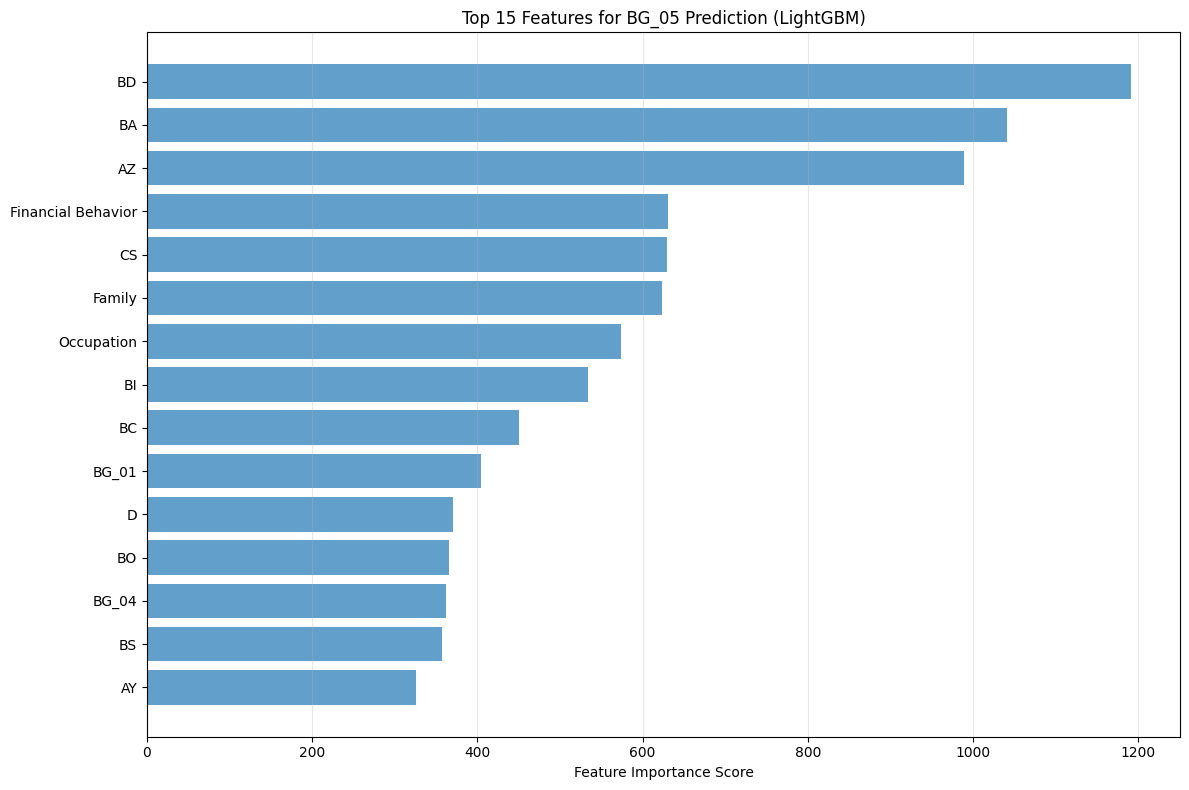

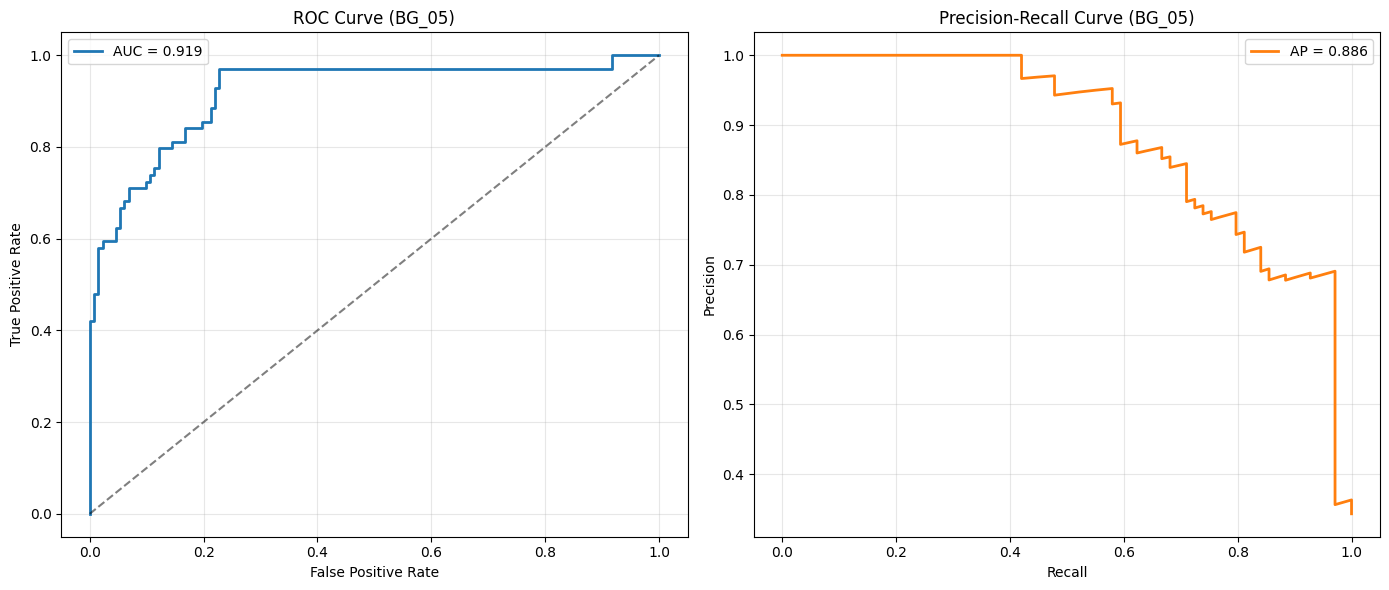

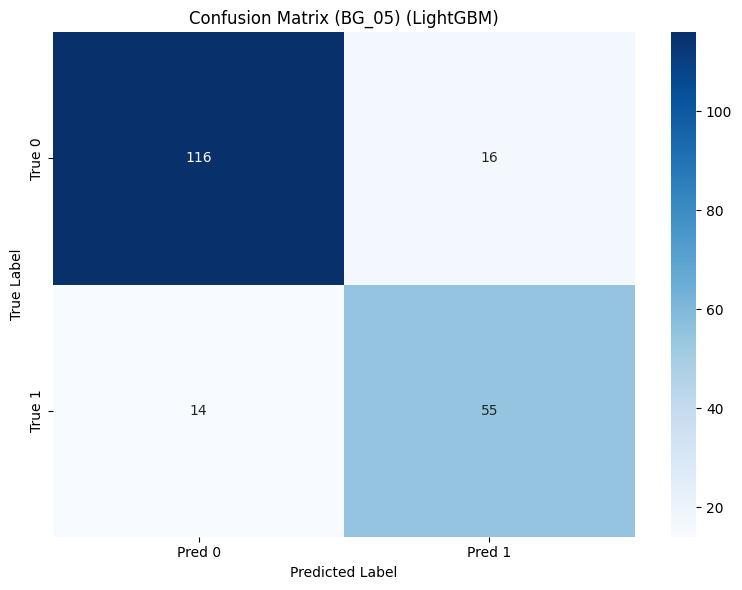

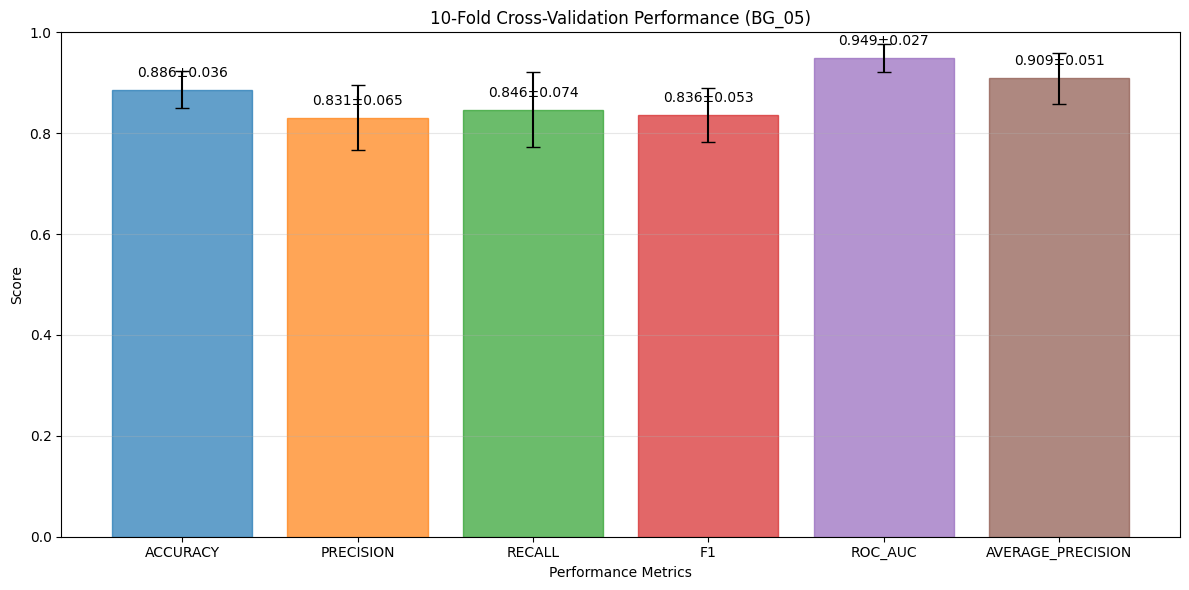


💾 SAVING OUTPUTS to bg_05_comprehensive_outputs_lgbm/ ...
✅ Saved metrics, plots, predictions, and model.

✅ DONE.


In [ ]:
"""
Reusable LightGBM Pipeline for Microfinance Impact Analysis
----------------------------------------------------------
Matches your RF/XGBoost pipeline structure:
- Universal target detection (CI, BF1, BF_1, BF 1, bf-1, etc.)
- Median imputation + StandardScaler in a Pipeline
- 10-fold Stratified CV with multiple metrics
- Train/Test/Validation split option
- Comprehensive evaluation + plots + saving outputs (metrics, preds, model, feature importances)

NOTE:
- This is for binary classification (0/1 target).
"""

# ==============
# 0) INSTALLS
# ==============
# If you're in Colab, uncomment:
# !pip -q install lightgbm openpyxl joblib

# ===========
# 0) IMPORTS
# ===========
import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

from lightgbm import LGBMClassifier

RANDOM_STATE = 42


# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e


def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df


# =========================================================
# 2) UNIVERSAL TARGET SELECTION
# =========================================================
def detect_target_column(df: pd.DataFrame, target: str) -> str:
    """
    Universal target detector:
    1) If `target` matches an existing column exactly -> use it.
    2) If target looks like BF<number>, try common BF aliases (BF 1, BF_1, bf-1, etc.).
    3) Else try case-insensitive exact match.
    4) Else ask user to type exact column name.
    """
    if target is None or str(target).strip() == "":
        raise ValueError("target cannot be empty. Example: target='CI' or target='BF1'")

    target = str(target).strip()

    # (1) Exact match
    if target in df.columns:
        print(f"🎯 Found target column (exact): {target}")
        return target

    # (2) BF alias support if user typed BF-style
    m = re.match(r"^\s*BF\s*(\d+)\s*$", target, flags=re.I)
    if m:
        k = m.group(1)
        aliases = [
            f"BF{k}", f"bf{k}",
            f"BF {k}", f"bf {k}",
            f"BF_{k}", f"bf_{k}",
            f"BF-{k}", f"bf-{k}",
        ]
        for a in aliases:
            if a in df.columns:
                print(f"🎯 Found target column (BF alias): {a}")
                return a

        pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
        for col in df.columns:
            if pat.search(str(col)):
                print(f"🎯 Found target column (BF regex): {col}")
                return col

    # (3) Case-insensitive exact match
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    if target.lower() in lower_map:
        real_col = lower_map[target.lower()]
        print(f"🎯 Found target column (case-insensitive): {real_col}")
        return real_col

    # (4) Ask user
    print(f"❌ Target column '{target}' not found automatically.")
    print("📊 Available columns:")
    print(df.columns.tolist())
    user_col = input("🔍 Enter the exact target column name: ").strip()
    if user_col in df.columns:
        print(f"✅ Using specified target column: {user_col}")
        return user_col
    raise ValueError(f"Column '{user_col}' not found in dataset")


def preprocess_target_binary(y_series: pd.Series, target_label: str):
    """
    Convert target responses into binary classification (expects 0/1 after cleaning).
    """
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label} after cleaning")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:")
    print(y_clean.value_counts().sort_index())

    unique_vals = sorted(y_clean.unique())
    print(f"Unique values: {unique_vals}")

    y_binary = y_clean.astype(int)

    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask


# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    """Prepare features for ML (numeric-only)."""
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    print(f"📊 Found {len(numeric_cols)} numeric features")

    if len(numeric_cols) == 0:
        raise ValueError("❌ No numeric features found for modeling")

    print("🔄 Handling missing values with median imputation...")
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    dropped = len(numeric_cols) - len(non_constant_cols)
    if dropped > 0:
        print(f"🗑️  Removed {dropped} constant columns")

    X_final = X_imputed[non_constant_cols]
    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols


# =========================================================
# 4) CROSS-VALIDATION
# =========================================================
def _compute_class_weight_for_lgbm(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    if pos == 0:
        return 1.0
    return neg / pos


def perform_cross_validation(X, y, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION")
    print("=" * 50)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        test_mean = float(np.mean(test_scores))
        test_std = float(np.std(test_scores))
        train_mean = float(np.mean(train_scores))

        metrics_summary[metric] = {
            "test_mean": test_mean,
            "test_std": test_std,
            "train_mean": train_mean
        }

        print(f"{metric.upper():<15}: {test_mean:.4f} ± {test_std:.4f} (train: {train_mean:.4f})")

    overfit_gap = metrics_summary["accuracy"]["train_mean"] - metrics_summary["accuracy"]["test_mean"]
    print(f"\n📈 Overfitting Analysis:")
    print(f"   Train-Test Accuracy Gap: {overfit_gap:.4f}")
    print("   ⚠️  Potential overfitting detected" if overfit_gap > 0.05 else "   ✅ Model generalizes well")

    return metrics_summary, cv_results


# =========================================================
# 5) TRAIN/TEST/VALIDATION SPLITS + TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING VALIDATION SET ({validation_size*100:.0f}% of data)")
    print("=" * 50)

    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )

    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print(f"✅ Validation set: {X_val.shape[0]} samples")

    return X_train, X_test, X_val, y_train, y_test, y_val


def train_with_comprehensive_validation(X, y, use_validation_set=True):
    print("\n🎯 MODEL TRAINING: LightGBM")
    print("-" * 40)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
        print("🔧 Training model with regularization...")
        pipe.fit(X_train, y_train)
        return pipe, X_train, X_test, X_val, y_train, y_test, y_val

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print("🔧 Training model with regularization...")
    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, None, y_train, y_test, None


# =========================================================
# 6) EVALUATION
# =========================================================
def evaluate_model_comprehensive(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET COMPREHENSIVE EVALUATION")
    print("=" * 60)
    print(f"🎯 Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"🎯 Recall:    {rec:.4f}")
    print(f"🎯 F1-Score:  {f1:.4f}")
    print(f"📈 ROC-AUC:   {roc_auc:.4f}")
    print(f"📈 PR-AUC:    {pr_auc:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    print(f"📊 {dataset_name} Confusion Matrix:")
    print("[[TN FP]\n [FN TP]]")
    print(cm)

    return y_pred, y_proba, {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc
    }


# =========================================================
# 7) VISUALIZATIONS
# =========================================================
def create_validation_comparison_plot(cv_metrics, output_dir, prefix):
    metrics_names = list(cv_metrics.keys())
    test_means = [cv_metrics[m]["test_mean"] for m in metrics_names]
    test_stds = [cv_metrics[m]["test_std"] for m in metrics_names]

    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(metrics_names))
    bars = plt.bar(x_pos, test_means, yerr=test_stds, capsize=5, alpha=0.7)

    for i, b in enumerate(bars):
        b.set_color(f"C{i}")

    plt.xlabel("Performance Metrics")
    plt.ylabel("Score")
    plt.title(f"10-Fold Cross-Validation Performance ({prefix.upper()})")
    plt.xticks(x_pos, [m.upper() for m in metrics_names], rotation=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis="y")

    for i, (mean, std) in enumerate(zip(test_means, test_stds)):
        plt.text(i, mean + 0.02, f"{mean:.3f}±{std:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_cross_validation_results.png", dpi=200, bbox_inches="tight")
    plt.show()


def create_comprehensive_visualizations(y_test, y_proba, model, feature_names, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    lgbm_model = model.named_steps["lgbm"]
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": lgbm_model.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"{output_dir}/{prefix}_feature_importances.csv", index=False)

    # Feature importance plot
    plt.figure(figsize=(12, 8))
    top_features = imp_df.head(15).iloc[::-1]
    plt.barh(range(len(top_features)), top_features["importance"], alpha=0.7)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Feature Importance Score")
    plt.title(f"Top 15 Features for {prefix.upper()} Prediction (LightGBM)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_feature_importances.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ROC + PR curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve ({prefix.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision-Recall Curve ({prefix.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Confusion matrix heatmap
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({prefix.upper()}) (LightGBM)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    if cv_metrics:
        create_validation_comparison_plot(cv_metrics, output_dir, prefix)

    return imp_df


# =========================================================
# 8) SAVE RESULTS
# =========================================================
def save_comprehensive_results(model, metrics, imp_df, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")
    os.makedirs(output_dir, exist_ok=True)

    with open(f"{output_dir}/{prefix}_comprehensive_metrics.txt", "w", encoding="utf-8") as f:
        f.write(f"COMPREHENSIVE LIGHTGBM RESULTS ({prefix.upper()})\n")
        f.write("=" * 60 + "\n")
        f.write(f"Dataset shape: {df_clean.shape}\n")
        f.write(f"Target column: {target_col}\n")
        f.write(f"Features used: {len(feature_names)}\n\n")

        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v:.4f}\n")
        f.write("\n")

        if cv_metrics:
            f.write("10-FOLD CROSS-VALIDATION (Mean ± Std) WITH MULTIPLE METRICS:\n")
            for metric, scores in cv_metrics.items():
                f.write(f"{metric}: {scores['test_mean']:.4f} ± {scores['test_std']:.4f}\n")
            f.write("\n")

        f.write("TOP 10 FEATURES:\n")
        for _, row in imp_df.head(10).iterrows():
            f.write(f"{row['feature']}: {row['importance']:.6f}\n")

    # Full-dataset predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore")
    X_full = X_full.reindex(columns=feature_names)

    preds = model.predict_proba(X_full)[:, 1]
    predictions_df = df_clean.copy()
    predictions_df[f"{prefix}_Pred_Prob"] = preds
    predictions_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    predictions_df[f"{prefix}_Correct"] = (predictions_df[f"{prefix}_Pred"] == predictions_df[target_col]).astype(int)

    predictions_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)
    joblib.dump(model, f"{output_dir}/{prefix}_lgbm_model.joblib")

    print("✅ Saved metrics, plots, predictions, and model.")


# =========================================================
# 9) MAIN PIPELINE (ASK TARGET AT THE END)
# =========================================================
def run_comprehensive_analysis(
    use_cross_validation=True,
    use_validation_set=True,
    df=None
):
    """
    Same pipeline, but you TYPE the target column at the end (after file load).
    """
    try:
        print("🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)")
        print("=" * 60)

        if df is None:
            try:
                import google.colab  # noqa: F401
                df = load_excel_from_colab()
            except Exception:
                df = load_excel_locally()

        print(f"📊 Initial dataset shape: {df.shape}")
        print("=" * 60)

        # ✅ Ask target at the end (after dataset is loaded)
        target = input("🎯 Enter target column (e.g., CI, BF1, BF3): ").strip()

        prefix = re.sub(r"[^a-zA-Z0-9]+", "_", str(target).strip().lower()).strip("_")
        output_dir = f"{prefix}_comprehensive_outputs_lgbm"

        print(f"\n🎯 Target: {target}")
        print(f"📁 Output folder: {output_dir}/")
        print("=" * 60)

        target_col = detect_target_column(df, target=target)

        y, valid_mask = preprocess_target_binary(df[target_col], target_label=target_col)
        df_clean = df.loc[valid_mask].copy()
        print(f"✅ Clean dataset: {df_clean.shape} (after removing invalid target rows)")

        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        cv_metrics = None
        if use_cross_validation:
            cv_metrics, _ = perform_cross_validation(X_final, y, cv_folds=10)

        model, X_train, X_test, X_val, y_train, y_test, y_val = train_with_comprehensive_validation(
            X_final, y, use_validation_set=use_validation_set
        )

        _, y_proba, test_metrics = evaluate_model_comprehensive(model, X_test, y_test, "Test")

        if X_val is not None and y_val is not None:
            evaluate_model_comprehensive(model, X_val, y_val, "Validation")

        imp_df = create_comprehensive_visualizations(
            y_test=y_test,
            y_proba=y_proba,
            model=model,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        save_comprehensive_results(
            model=model,
            metrics=test_metrics,
            imp_df=imp_df,
            df_clean=df_clean,
            target_col=target_col,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        print("\n✅ DONE.")
        return model, test_metrics, imp_df, cv_metrics

    except Exception as e:
        print(f"\n❌ Analysis failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc(limit=2)
        return None, None, None, None


# ========= RUN =========
if __name__ == "__main__":
    # You will be asked to upload the file, then type the target column name
    run_comprehensive_analysis(use_cross_validation=True, use_validation_set=True)


🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)
📁 Please select the Excel file with your encoded dataset...


Saving rf_dataset_encoded_dataset.xlsx to rf_dataset_encoded_dataset (4).xlsx
✅ Loaded dataset: (1002, 85) (rows, cols)
📊 Initial dataset shape: (1002, 85)
🎯 Enter target column (e.g., CI, BF1, BF3): BG_06

🎯 Target: BG_06
📁 Output folder: bg_06_comprehensive_outputs_lgbm/
🎯 Found target column (exact): BG_06

📈 TARGET ANALYSIS: BG_06
----------------------------------------
Value distribution:
BG_06
0    783
1    219
Name: count, dtype: int64
Unique values: [np.int64(0), np.int64(1)]
🎯 Final class balance: {0: 0.781, 1: 0.219}
✅ Clean dataset: (1002, 85) (after removing invalid target rows)

🔧 FEATURE ENGINEERING
----------------------------------------
📊 Found 84 numeric features
🔄 Handling missing values with median imputation...
✅ Final feature matrix: (1002, 84) (rows, cols)

🔍 PERFORMING 10-FOLD CROSS-VALIDATION
📊 CROSS-VALIDATION RESULTS (Mean ± Std):
----------------------------------------
ACCURACY       : 0.9051 ± 0.0356 (train: 0.9993)
PRECISION      : 0.8106 ± 0.0880 (train

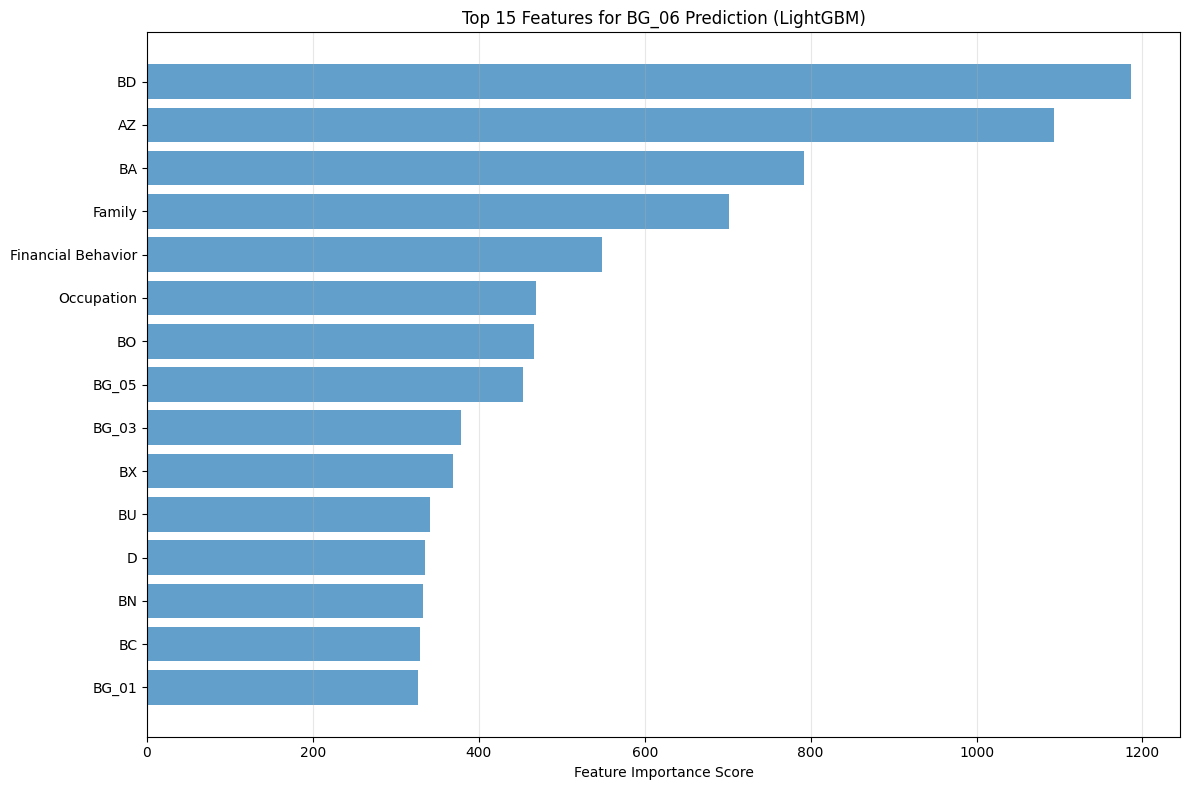

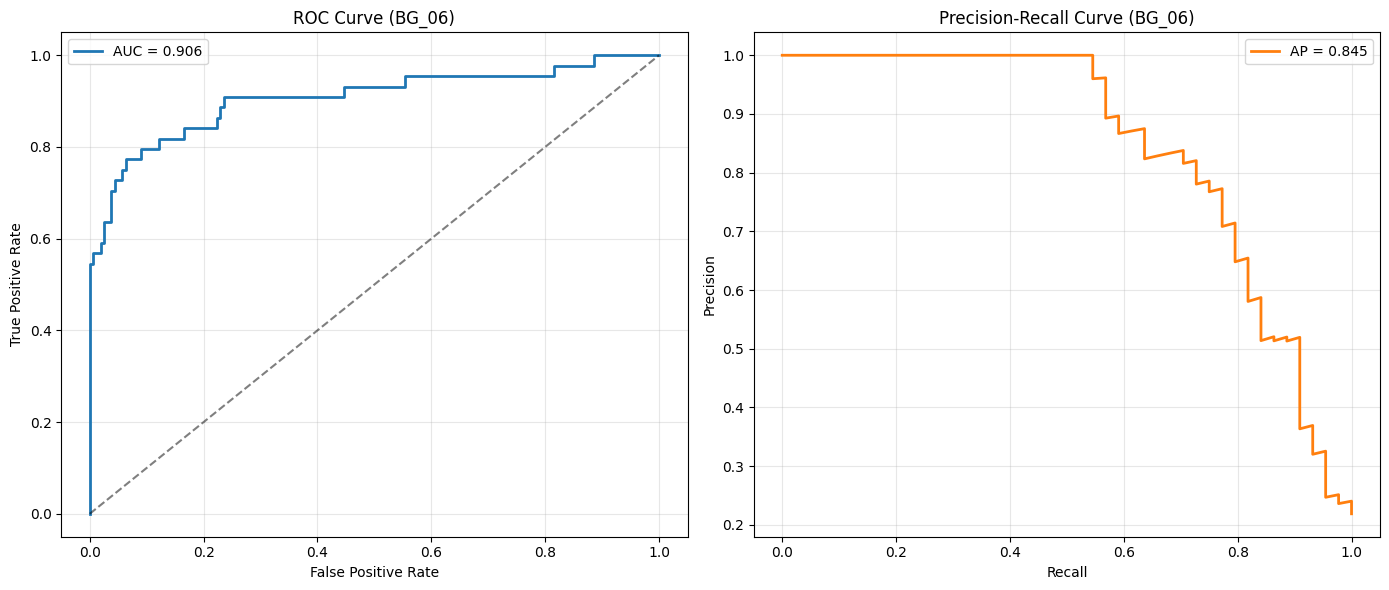

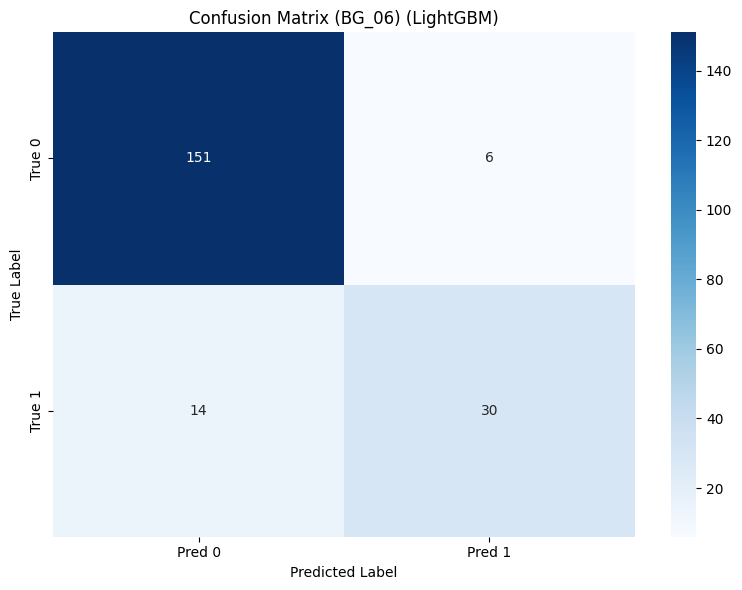

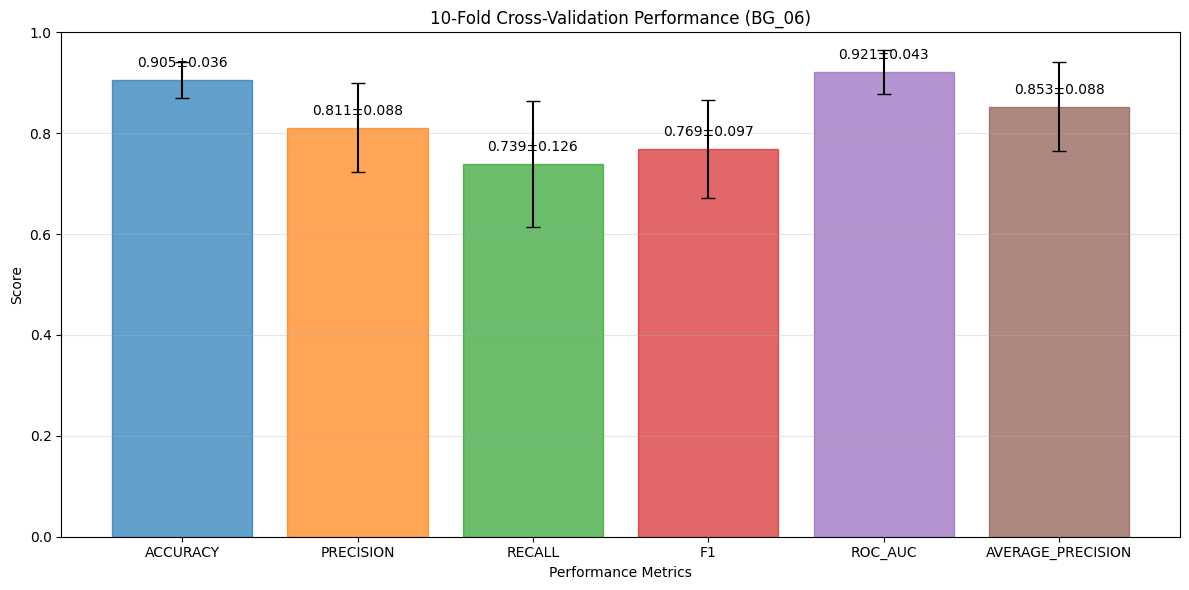


💾 SAVING OUTPUTS to bg_06_comprehensive_outputs_lgbm/ ...
✅ Saved metrics, plots, predictions, and model.

✅ DONE.


In [ ]:
"""
Reusable LightGBM Pipeline for Microfinance Impact Analysis
----------------------------------------------------------
Matches your RF/XGBoost pipeline structure:
- Universal target detection (CI, BF1, BF_1, BF 1, bf-1, etc.)
- Median imputation + StandardScaler in a Pipeline
- 10-fold Stratified CV with multiple metrics
- Train/Test/Validation split option
- Comprehensive evaluation + plots + saving outputs (metrics, preds, model, feature importances)

NOTE:
- This is for binary classification (0/1 target).
"""

# ==============
# 0) INSTALLS
# ==============
# If you're in Colab, uncomment:
# !pip -q install lightgbm openpyxl joblib

# ===========
# 0) IMPORTS
# ===========
import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

from lightgbm import LGBMClassifier

RANDOM_STATE = 42


# =========================================================
# 1) DATA LOADING
# =========================================================
def load_excel_from_colab():
    """Upload Excel in Google Colab."""
    try:
        from google.colab import files
        print("📁 Please select the Excel file with your encoded dataset...")
        uploaded = files.upload()
        path = list(uploaded.keys())[0]
        df = pd.read_excel(path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        raise RuntimeError("Colab upload failed.") from e


def load_excel_locally():
    """Upload Excel when running locally."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        print("📁 Please select the Excel file...")
        root = tk.Tk()
        root.withdraw()
        file_path = filedialog.askopenfilename(
            title="Select Excel file",
            filetypes=[("Excel files", "*.xlsx *.xls")]
        )
        if not file_path:
            raise ValueError("No file selected")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df
    except Exception as e:
        print(f"❌ File dialog failed: {e}")
        file_path = input("📁 Enter full path to your Excel file: ")
        df = pd.read_excel(file_path)
        print(f"✅ Loaded dataset: {df.shape} (rows, cols)")
        return df


# =========================================================
# 2) UNIVERSAL TARGET SELECTION
# =========================================================
def detect_target_column(df: pd.DataFrame, target: str) -> str:
    """
    Universal target detector:
    1) If `target` matches an existing column exactly -> use it.
    2) If target looks like BF<number>, try common BF aliases (BF 1, BF_1, bf-1, etc.).
    3) Else try case-insensitive exact match.
    4) Else ask user to type exact column name.
    """
    if target is None or str(target).strip() == "":
        raise ValueError("target cannot be empty. Example: target='CI' or target='BF1'")

    target = str(target).strip()

    # (1) Exact match
    if target in df.columns:
        print(f"🎯 Found target column (exact): {target}")
        return target

    # (2) BF alias support if user typed BF-style
    m = re.match(r"^\s*BF\s*(\d+)\s*$", target, flags=re.I)
    if m:
        k = m.group(1)
        aliases = [
            f"BF{k}", f"bf{k}",
            f"BF {k}", f"bf {k}",
            f"BF_{k}", f"bf_{k}",
            f"BF-{k}", f"bf-{k}",
        ]
        for a in aliases:
            if a in df.columns:
                print(f"🎯 Found target column (BF alias): {a}")
                return a

        pat = re.compile(rf"\bbf\s*[_-]?\s*{k}\b", flags=re.I)
        for col in df.columns:
            if pat.search(str(col)):
                print(f"🎯 Found target column (BF regex): {col}")
                return col

    # (3) Case-insensitive exact match
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    if target.lower() in lower_map:
        real_col = lower_map[target.lower()]
        print(f"🎯 Found target column (case-insensitive): {real_col}")
        return real_col

    # (4) Ask user
    print(f"❌ Target column '{target}' not found automatically.")
    print("📊 Available columns:")
    print(df.columns.tolist())
    user_col = input("🔍 Enter the exact target column name: ").strip()
    if user_col in df.columns:
        print(f"✅ Using specified target column: {user_col}")
        return user_col
    raise ValueError(f"Column '{user_col}' not found in dataset")


def preprocess_target_binary(y_series: pd.Series, target_label: str):
    """
    Convert target responses into binary classification (expects 0/1 after cleaning).
    """
    y_numeric = pd.to_numeric(y_series, errors="coerce")
    valid_mask = y_numeric.notna() & np.isfinite(y_numeric)
    y_clean = y_numeric[valid_mask]

    if len(y_clean) == 0:
        raise ValueError(f"❌ No valid values for {target_label} after cleaning")

    print(f"\n📈 TARGET ANALYSIS: {target_label}")
    print("-" * 40)
    print("Value distribution:")
    print(y_clean.value_counts().sort_index())

    unique_vals = sorted(y_clean.unique())
    print(f"Unique values: {unique_vals}")

    y_binary = y_clean.astype(int)

    class_balance = y_binary.value_counts(normalize=True).round(3)
    print(f"🎯 Final class balance: {class_balance.to_dict()}")

    return y_binary, valid_mask


# =========================================================
# 3) FEATURE ENGINEERING
# =========================================================
def build_feature_matrix(df_clean: pd.DataFrame, target_col: str):
    """Prepare features for ML (numeric-only)."""
    print("\n🔧 FEATURE ENGINEERING")
    print("-" * 40)

    X = df_clean.drop(columns=[target_col], errors="ignore")
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    print(f"📊 Found {len(numeric_cols)} numeric features")

    if len(numeric_cols) == 0:
        raise ValueError("❌ No numeric features found for modeling")

    print("🔄 Handling missing values with median imputation...")
    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(X[numeric_cols])
    X_imputed = pd.DataFrame(X_imputed, columns=numeric_cols, index=X.index)

    non_constant_cols = [c for c in X_imputed.columns if X_imputed[c].nunique() > 1]
    dropped = len(numeric_cols) - len(non_constant_cols)
    if dropped > 0:
        print(f"🗑️  Removed {dropped} constant columns")

    X_final = X_imputed[non_constant_cols]
    print(f"✅ Final feature matrix: {X_final.shape} (rows, cols)")
    return X_final, non_constant_cols


# =========================================================
# 4) CROSS-VALIDATION
# =========================================================
def _compute_class_weight_for_lgbm(y):
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    if pos == 0:
        return 1.0
    return neg / pos


def perform_cross_validation(X, y, cv_folds=10):
    print(f"\n🔍 PERFORMING {cv_folds}-FOLD CROSS-VALIDATION")
    print("=" * 50)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }

    cv_results = cross_validate(
        pipe, X, y,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    print("📊 CROSS-VALIDATION RESULTS (Mean ± Std):")
    print("-" * 40)

    metrics_summary = {}
    for metric in scoring.keys():
        test_scores = cv_results[f"test_{metric}"]
        train_scores = cv_results[f"train_{metric}"]

        test_mean = float(np.mean(test_scores))
        test_std = float(np.std(test_scores))
        train_mean = float(np.mean(train_scores))

        metrics_summary[metric] = {
            "test_mean": test_mean,
            "test_std": test_std,
            "train_mean": train_mean
        }

        print(f"{metric.upper():<15}: {test_mean:.4f} ± {test_std:.4f} (train: {train_mean:.4f})")

    overfit_gap = metrics_summary["accuracy"]["train_mean"] - metrics_summary["accuracy"]["test_mean"]
    print(f"\n📈 Overfitting Analysis:")
    print(f"   Train-Test Accuracy Gap: {overfit_gap:.4f}")
    print("   ⚠️  Potential overfitting detected" if overfit_gap > 0.05 else "   ✅ Model generalizes well")

    return metrics_summary, cv_results


# =========================================================
# 5) TRAIN/TEST/VALIDATION SPLITS + TRAINING
# =========================================================
def create_validation_set(X, y, validation_size=0.2):
    print(f"\n🔍 CREATING VALIDATION SET ({validation_size*100:.0f}% of data)")
    print("=" * 50)

    X_train_test, X_val, y_train_test, y_val = train_test_split(
        X, y, test_size=validation_size, stratify=y, random_state=RANDOM_STATE
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_train_test, y_train_test, test_size=0.25, stratify=y_train_test, random_state=RANDOM_STATE
    )

    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print(f"✅ Validation set: {X_val.shape[0]} samples")

    return X_train, X_test, X_val, y_train, y_test, y_val


def train_with_comprehensive_validation(X, y, use_validation_set=True):
    print("\n🎯 MODEL TRAINING: LightGBM")
    print("-" * 40)

    preprocessor = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ])

    spw = _compute_class_weight_for_lgbm(y)

    lgbm = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=spw,
        verbosity=-1
    )

    pipe = Pipeline([("pre", preprocessor), ("lgbm", lgbm)])

    if use_validation_set:
        X_train, X_test, X_val, y_train, y_test, y_val = create_validation_set(X, y)
        print("🔧 Training model with regularization...")
        pipe.fit(X_train, y_train)
        return pipe, X_train, X_test, X_val, y_train, y_test, y_val

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
    )
    print(f"📚 Training set: {X_train.shape[0]} samples")
    print(f"🧪 Test set: {X_test.shape[0]} samples")
    print("🔧 Training model with regularization...")
    pipe.fit(X_train, y_train)
    return pipe, X_train, X_test, None, y_train, y_test, None


# =========================================================
# 6) EVALUATION
# =========================================================
def evaluate_model_comprehensive(model, X_test, y_test, dataset_name="Test"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    print("\n" + "=" * 60)
    print(f"📊 {dataset_name.upper()} SET COMPREHENSIVE EVALUATION")
    print("=" * 60)
    print(f"🎯 Accuracy:  {acc:.4f}")
    print(f"🎯 Precision: {prec:.4f}")
    print(f"🎯 Recall:    {rec:.4f}")
    print(f"🎯 F1-Score:  {f1:.4f}")
    print(f"📈 ROC-AUC:   {roc_auc:.4f}")
    print(f"📈 PR-AUC:    {pr_auc:.4f}")

    print(f"\n📋 {dataset_name} Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    print(f"📊 {dataset_name} Confusion Matrix:")
    print("[[TN FP]\n [FN TP]]")
    print(cm)

    return y_pred, y_proba, {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "roc_auc": roc_auc, "pr_auc": pr_auc
    }


# =========================================================
# 7) VISUALIZATIONS
# =========================================================
def create_validation_comparison_plot(cv_metrics, output_dir, prefix):
    metrics_names = list(cv_metrics.keys())
    test_means = [cv_metrics[m]["test_mean"] for m in metrics_names]
    test_stds = [cv_metrics[m]["test_std"] for m in metrics_names]

    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(metrics_names))
    bars = plt.bar(x_pos, test_means, yerr=test_stds, capsize=5, alpha=0.7)

    for i, b in enumerate(bars):
        b.set_color(f"C{i}")

    plt.xlabel("Performance Metrics")
    plt.ylabel("Score")
    plt.title(f"10-Fold Cross-Validation Performance ({prefix.upper()})")
    plt.xticks(x_pos, [m.upper() for m in metrics_names], rotation=0)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis="y")

    for i, (mean, std) in enumerate(zip(test_means, test_stds)):
        plt.text(i, mean + 0.02, f"{mean:.3f}±{std:.3f}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_cross_validation_results.png", dpi=200, bbox_inches="tight")
    plt.show()


def create_comprehensive_visualizations(y_test, y_proba, model, feature_names, output_dir, prefix, cv_metrics=None):
    os.makedirs(output_dir, exist_ok=True)

    lgbm_model = model.named_steps["lgbm"]
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": lgbm_model.feature_importances_
    }).sort_values("importance", ascending=False)

    imp_df.to_csv(f"{output_dir}/{prefix}_feature_importances.csv", index=False)

    # Feature importance plot
    plt.figure(figsize=(12, 8))
    top_features = imp_df.head(15).iloc[::-1]
    plt.barh(range(len(top_features)), top_features["importance"], alpha=0.7)
    plt.yticks(range(len(top_features)), top_features["feature"])
    plt.xlabel("Feature Importance Score")
    plt.title(f"Top 15 Features for {prefix.upper()} Prediction (LightGBM)")
    plt.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_feature_importances.png", dpi=200, bbox_inches="tight")
    plt.show()

    # ROC + PR curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", linewidth=2, color="C0")
    ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_title(f"ROC Curve ({prefix.upper()})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(recall_vals, precision_vals, label=f"AP = {pr_auc:.3f}", linewidth=2, color="C1")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title(f"Precision-Recall Curve ({prefix.upper()})")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Confusion matrix heatmap
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    plt.title(f"Confusion Matrix ({prefix.upper()}) (LightGBM)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{prefix}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    if cv_metrics:
        create_validation_comparison_plot(cv_metrics, output_dir, prefix)

    return imp_df


# =========================================================
# 8) SAVE RESULTS
# =========================================================
def save_comprehensive_results(model, metrics, imp_df, df_clean, target_col, feature_names, output_dir, prefix, cv_metrics=None):
    print(f"\n💾 SAVING OUTPUTS to {output_dir}/ ...")
    os.makedirs(output_dir, exist_ok=True)

    with open(f"{output_dir}/{prefix}_comprehensive_metrics.txt", "w", encoding="utf-8") as f:
        f.write(f"COMPREHENSIVE LIGHTGBM RESULTS ({prefix.upper()})\n")
        f.write("=" * 60 + "\n")
        f.write(f"Dataset shape: {df_clean.shape}\n")
        f.write(f"Target column: {target_col}\n")
        f.write(f"Features used: {len(feature_names)}\n\n")

        f.write("TEST SET METRICS:\n")
        for k, v in metrics.items():
            f.write(f"{k}: {v:.4f}\n")
        f.write("\n")

        if cv_metrics:
            f.write("10-FOLD CROSS-VALIDATION (Mean ± Std) WITH MULTIPLE METRICS:\n")
            for metric, scores in cv_metrics.items():
                f.write(f"{metric}: {scores['test_mean']:.4f} ± {scores['test_std']:.4f}\n")
            f.write("\n")

        f.write("TOP 10 FEATURES:\n")
        for _, row in imp_df.head(10).iterrows():
            f.write(f"{row['feature']}: {row['importance']:.6f}\n")

    # Full-dataset predictions
    X_full = df_clean.drop(columns=[target_col], errors="ignore")
    X_full = X_full.reindex(columns=feature_names)

    preds = model.predict_proba(X_full)[:, 1]
    predictions_df = df_clean.copy()
    predictions_df[f"{prefix}_Pred_Prob"] = preds
    predictions_df[f"{prefix}_Pred"] = (preds >= 0.5).astype(int)
    predictions_df[f"{prefix}_Correct"] = (predictions_df[f"{prefix}_Pred"] == predictions_df[target_col]).astype(int)

    predictions_df.to_excel(f"{output_dir}/{prefix}_predictions.xlsx", index=False)
    joblib.dump(model, f"{output_dir}/{prefix}_lgbm_model.joblib")

    print("✅ Saved metrics, plots, predictions, and model.")


# =========================================================
# 9) MAIN PIPELINE (ASK TARGET AT THE END)
# =========================================================
def run_comprehensive_analysis(
    use_cross_validation=True,
    use_validation_set=True,
    df=None
):
    """
    Same pipeline, but you TYPE the target column at the end (after file load).
    """
    try:
        print("🚀 COMPREHENSIVE MICROFINANCE ANALYSIS (LightGBM)")
        print("=" * 60)

        if df is None:
            try:
                import google.colab  # noqa: F401
                df = load_excel_from_colab()
            except Exception:
                df = load_excel_locally()

        print(f"📊 Initial dataset shape: {df.shape}")
        print("=" * 60)

        # ✅ Ask target at the end (after dataset is loaded)
        target = input("🎯 Enter target column (e.g., CI, BF1, BF3): ").strip()

        prefix = re.sub(r"[^a-zA-Z0-9]+", "_", str(target).strip().lower()).strip("_")
        output_dir = f"{prefix}_comprehensive_outputs_lgbm"

        print(f"\n🎯 Target: {target}")
        print(f"📁 Output folder: {output_dir}/")
        print("=" * 60)

        target_col = detect_target_column(df, target=target)

        y, valid_mask = preprocess_target_binary(df[target_col], target_label=target_col)
        df_clean = df.loc[valid_mask].copy()
        print(f"✅ Clean dataset: {df_clean.shape} (after removing invalid target rows)")

        X_final, feature_names = build_feature_matrix(df_clean, target_col)

        cv_metrics = None
        if use_cross_validation:
            cv_metrics, _ = perform_cross_validation(X_final, y, cv_folds=10)

        model, X_train, X_test, X_val, y_train, y_test, y_val = train_with_comprehensive_validation(
            X_final, y, use_validation_set=use_validation_set
        )

        _, y_proba, test_metrics = evaluate_model_comprehensive(model, X_test, y_test, "Test")

        if X_val is not None and y_val is not None:
            evaluate_model_comprehensive(model, X_val, y_val, "Validation")

        imp_df = create_comprehensive_visualizations(
            y_test=y_test,
            y_proba=y_proba,
            model=model,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        save_comprehensive_results(
            model=model,
            metrics=test_metrics,
            imp_df=imp_df,
            df_clean=df_clean,
            target_col=target_col,
            feature_names=feature_names,
            output_dir=output_dir,
            prefix=prefix,
            cv_metrics=cv_metrics
        )

        print("\n✅ DONE.")
        return model, test_metrics, imp_df, cv_metrics

    except Exception as e:
        print(f"\n❌ Analysis failed: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc(limit=2)
        return None, None, None, None


# ========= RUN =========
if __name__ == "__main__":
    # You will be asked to upload the file, then type the target column name
    run_comprehensive_analysis(use_cross_validation=True, use_validation_set=True)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install the package for Tex and then convert to PDF directly as LaTex
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
# Provide the file path of the notebook file inside the quotations
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/CSE thesis LightGBM P3.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr